# 📧🧴 De la bandeja de entrada al RAG: vectorización de emails con BigQuery

**Curso práctico · ~90 minutos · Google Colab + BigQuery**

Trabajamos para **Esencia Ibérica, S.L.**, una tienda online de perfumes. Cada día recibe decenas de emails: consultas sobre productos, estados de pedido, quejas, devoluciones... Vamos a construir, paso a paso, un sistema **RAG (Retrieval-Augmented Generation)** que permite *preguntar en lenguaje natural* sobre todo ese correo.

**Idea central del curso:** los emails se cargan en una **tabla de BigQuery**, y todo lo demás —limpieza, vectorización, búsqueda semántica— ocurre **en SQL, dentro de la base de datos**. Nada de PDFs, ficheros intermedios ni vector stores externos: la tabla SQL *es* el vector store.

## ⚖️ La primera decisión de diseño: ¿documentos sueltos o base de datos?

Antes de escribir una línea de código hay que tomar una decisión de arquitectura, y merece argumentarse porque **la otra opción también existe** y es la que enseñan la mayoría de tutoriales de RAG:

**Opción A — tratar cada email como un documento** (un `.txt`/`.pdf` por email, cargarlos con un framework tipo LlamaIndex, vectorizarlos hacia un vector store externo). Es el camino natural cuando tu fuente *son* ficheros: manuales en PDF, contratos, páginas web.

**Opción B — meterlos en una base de datos** (nuestra elección). ¿Por qué?

1. **Los emails ya nacen estructurados.** Remitente, fecha, asunto, hilo, destinatario... Convertirlos en ficheros sueltos sería *destruir* esa estructura para luego tener que reconstruirla a mano como "metadatos" del vector store. En una tabla, cada dato es una columna desde el minuto uno.
2. **El RAG necesitará esos campos, no solo el texto.** "Quejas *del último trimestre*", "emails *de este proveedor*"... son filtros SQL sobre columnas (sección 6). Con documentos sueltos, cada filtro es una feature que tienes que programar; con una BD, es un `WHERE`.
3. **Los emails no paran de llegar.** Con ficheros, decidir cuáles son nuevos y vectorizar solo esos es un pipeline que debes construir y mantener. En una BD es un *anti-join* de una línea (sección 8) — un problema que las bases de datos resolvieron hace 40 años.
4. **Un sistema en vez de tres.** La opción A termina con ficheros en un bucket + un vector store + código de sincronización entre ambos (¿y si borras un email? ¿y los permisos?). En la opción B, texto, metadatos **y vectores son columnas de la misma tabla**: una sola copia del dato, un solo control de acceso, un solo lugar que auditar.
5. **El volumen.** 300 emails caben en cualquier sitio; 5 millones, no. Queremos que el mismo diseño sobreviva al crecimiento sin cambiar de arquitectura.

> 🎓 **Regla práctica:** si tu fuente son **ficheros sin estructura** (PDFs, manuales), el enfoque documental es razonable. Si tu fuente ya es **estructurada o semi-estructurada** (emails, tickets, CRM, tablas), llevarla a ficheros para "hacer RAG" es dar un rodeo: vectoriza donde ya vive el dato. Los emails son el ejemplo perfecto del segundo caso — y por eso este curso es *RAG sobre una base de datos*.

### Cómo está escrito este curso

Cada sección sigue el mismo patrón: primero el **porqué** (el concepto, que es válido uses la tecnología que uses) y después el **cómo** (la implementación concreta en BigQuery). Al final de las secciones clave hay un recuadro **🧭 Para llevar** con lo que seguiría siendo cierto si mañana cambiaras BigQuery por PostgreSQL + pgvector, Elasticsearch o Pinecone. Si dentro de un año no recuerdas ninguna sintaxis pero sí todos los porqués, el curso habrá funcionado.

## Arquitectura que vamos a montar

```
 Emails sintéticos          BigQuery                      BigQuery ML / Vertex AI
┌─────────────────┐   ┌──────────────────────┐   ┌─────────────────────────────────┐
│ Python + Faker  │──▶│ EXTRACT & LOAD       │──▶│ ML.GENERATE_EMBEDDING           │
│ (300 emails)    │   │ tabla emails_raw     │   │ (gemini-embedding-001)          │
└─────────────────┘   │ TRANSFORM            │   └───────────────┬─────────────────┘
                      │ limpieza + chunking  │                   │
                      └──────────────────────┘                   ▼
┌─────────────────┐   ┌──────────────────────┐   ┌─────────────────────────────────┐
│ Respuesta LLM   │◀──│ Gemini 2.5 Flash     │◀──│ VECTOR_SEARCH (top-k chunks)    │
│ con contexto    │   │ (generación)         │   │ distancia coseno                │
└─────────────────┘   └──────────────────────┘   └─────────────────────────────────┘
```

## Agenda

| ⏱️ | Sección |
|---|---|
| 5 min | 0. Setup: autenticación y dataset |
| 5 min | 1. Generación de emails sintéticos (ejecutar sin estudiar las plantillas) |
| 7 min | 2. **E**xtract & **L**oad → BigQuery |
| 10 min | 3. **T**ransform: limpieza y *chunking* |
| 5 min | 4. Conexión a Vertex AI y modelo remoto de embeddings |
| 20 min | 5. **Vectorización a fondo**: `ML.GENERATE_EMBEDDING`, `task_type`, dimensiones, geometría y visualización |
| 10 min | 6. Búsqueda semántica con `VECTOR_SEARCH` + filtros por metadatos |
| 15 min | 7. **De la búsqueda semántica al RAG**: retrieval + generación con Gemini |
| 5 min | 8. Vectorización incremental (patrón de producción) |
| 8 min | 9. Evaluación, ejercicios y limpieza |

*(Total: 90 min. Las celdas marcadas 🔬 OPCIONAL no cuentan en la agenda: en directo son demo del instructor o para casa.)*

## Requisitos previos (¡verifícalos ANTES de la clase!)

- Un **proyecto de GCP con facturación habilitada** y rol de **Propietario (Owner)** — Editor no basta: en la sección 4 tocamos permisos IAM. Cómo comprobarlo, paso a paso:
  - **¿No tienes proyecto?** [console.cloud.google.com](https://console.cloud.google.com) → selector de proyectos (arriba a la izquierda) → *Nuevo proyecto*.
  - **¿Tiene facturación?** Menú ☰ → *Facturación* → debe aparecer una cuenta de facturación vinculada al proyecto.
  - **¿Qué rol tengo?** Menú ☰ → *IAM y administración* → búscate en la lista: debe decir *Propietario*. (Alternativa si eres Editor: que un admin ejecute por ti la celda de permisos de la sección 4.)
  - **¿Cuál es mi `PROJECT_ID`?** En el selector de proyectos, la columna **ID** — ojo: es el *ID* (p. ej. `mi-proyecto-427811`), no el *nombre* ni el *número* del proyecto.
- Python y SQL básicos. No hace falta experiencia previa con embeddings, RAG ni GCP.

### 📋 Si este curso se imparte en directo: deberes previos

48 h antes de la clase, ejecuta las secciones **0 y 4** completas (autenticación, APIs, dataset, conexión y modelo remoto) y guarda un pantallazo del mensaje `✅ Modelo remoto de embeddings creado`. Así el directo empieza en la sección 1 y la propagación de permisos (que tarda minutos) ya ocurrió ayer. Hay 4 puntos 🚩 CHECKPOINT en el notebook para sincronizar al grupo.

*Nota para el instructor — guion de recortes si vas tarde:* primero las celdas 🔬 OPCIONALES (−8 min), luego la sección 8 como demo tuya en pantalla (−3 min), luego los ejercicios como deberes (−5 min). **Nunca recortes las secciones 4-7**: son el corazón del curso.

> 💰 **Coste estimado del laboratorio completo: < 0,50 €** (300 emails son pocos KB; los embeddings y las llamadas a Gemini con este volumen cuestan céntimos). Al final hay una celda de limpieza para borrar todos los recursos.

---
## 🧩 Antes de empezar: ¿qué es eso de "vectorizar"?

Llevamos ya varios párrafos diciendo *embedding*, *vector*, *vectorizar*... Pongamos la idea sobre la mesa antes de tocar código, porque es la base de todo el curso.

**Un vector es simplemente una lista de números** — y una lista de números es **un punto en un espacio**. Con 2 números, un punto en un plano; con 3, un punto en el espacio 3D; con 3072, un punto en un espacio que no podemos dibujar, pero que matemáticamente funciona igual.

**La intuición, en 2D.** Imagina que colocamos cada email en un plano con dos ejes inventados: eje X = "¿cuánto habla de un pedido?", eje Y = "¿cuánto enfado transmite?":

```
 enfado ▲
   1.0  │           ● queja "frasco roto" (0.9, 0.9)
        │
   0.5  │
        │  ● "¿qué perfume me                ● "¿dónde está mi
        │     recomendáis?" (0.1, 0.1)         pedido?" (0.9, 0.2)
   0.0  └────────────────────────────────────────▶ habla de pedido
       0.0            0.5                 1.0
```

Con solo **dos números por email** ya podemos hacer algo poderoso: **medir qué emails se parecen calculando la distancia entre sus puntos**. La queja y el "¿dónde está mi pedido?" están cerca en X (ambos hablan de pedidos) pero lejos en Y (solo una está enfadada). Buscar "clientes enfadados" sería buscar los puntos cercanos a la esquina superior.

**Un embedding es exactamente esto, pero con ~3.000 ejes que nadie diseñó a mano**: un modelo de IA, tras leer miles de millones de textos, aprendió solo qué "ejes" necesita para que *textos con significado parecido queden en puntos cercanos*. No sabemos qué mide cada eje individual (no tienen nombre), pero no importa: lo que usamos es la **cercanía**.

**"Vectorizar"** = pasar cada texto por ese modelo para obtener su punto. Y con eso, el plan del curso entero cabe en una frase: *convertir cada email en un punto (secciones 1-5), buscar los puntos más cercanos a una pregunta (sección 6) y darle esos emails a un LLM para que redacte la respuesta (sección 7).*

En la sección 5 volveremos sobre esto con detalle (y en la 5.5 **dibujaremos de verdad** nuestros 300 emails como puntos, proyectados a 2D). Por ahora, quédate con: **texto → punto; parecido → cerca; buscar → medir distancias.**

---
# 0 · Setup ⏱️ ~5 min

Autenticamos Colab contra GCP, instalamos dependencias y creamos el dataset de trabajo.

**Conceptos clave:**
- En Colab, `auth.authenticate_user()` da a las librerías cliente las credenciales de tu cuenta Google.
- Un **dataset** en BigQuery es el contenedor lógico de tablas y modelos (equivalente a un *schema*). Fijamos la ubicación (`US`) — todos los recursos (dataset, conexión, modelos) deben vivir en la **misma región**.

### ¿Qué instalamos y para qué?

| Librería | Papel en el curso |
|---|---|
| `google-cloud-bigquery` | El cliente Python de BigQuery: crear el dataset, lanzar consultas SQL y cargar DataFrames como tablas. Es el puente Colab ↔ BigQuery. |
| `faker` | Genera datos falsos realistas en español (nombres, ciudades, teléfonos, emails). La usamos solo en la sección 1, para fabricar los emails sintéticos. |
| `google-genai` | El SDK de Gemini. Lo usamos únicamente en el último paso del RAG (sección 7): la **G**eneración de la respuesta. |
| `pandas` | Los emails viven en memoria como DataFrame entre la generación y la carga; también nos da la vista tabular de los resultados de las consultas. |
| `db-dtypes` | Pieza pequeña pero necesaria: traduce los tipos de BigQuery (`TIMESTAMP`, `NUMERIC`...) a tipos de pandas. Sin ella, `to_dataframe()` falla. |

Colab ya trae preinstaladas varias de ellas; el `--upgrade` garantiza versiones recientes (p. ej., `google-genai` es nueva y cambia rápido). Usamos `%pip` (y no `!pip`) para asegurar que se instalan en el mismo entorno que ejecuta el notebook.

> ⚠️ Si tras instalar, Colab muestra un aviso de reiniciar el entorno, hazlo sin miedo (*Entorno de ejecución → Reiniciar*) y continúa desde la celda siguiente: es normal cuando se actualizan librerías compartidas.

In [1]:
%pip install --quiet --upgrade google-cloud-bigquery faker google-genai pandas db-dtypes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.3/264.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 984.2/984.2 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 53.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


▶️ **Qué hace esta celda:** te autentica con tu cuenta de Google, fija el proyecto de trabajo y habilita las 3 APIs que usaremos (BigQuery, Connections y Vertex AI). Es la única celda donde tienes que **editar algo**: tu `PROJECT_ID` — recuerda: el **ID** del proyecto (columna "ID" del selector de la consola), no su nombre ni su número. Habilitar las APIs no cuesta dinero.

> 🆘 **Si `gcloud services enable` falla**, en el 90% de los casos es facturación no vinculada al proyecto (revisa Menú ☰ → Facturación) o falta de permisos (necesitas Owner). El mensaje de error lo dice, aunque en inglés enrevesado: busca "billing" o "permission" en él.

In [4]:
from google.colab import auth
auth.authenticate_user()
print("✅ Autenticado")

# 👇 EDITA ESTO con tu proyecto
PROJECT_ID = "pingscores"  # @param {type:"string"}
LOCATION   = "US"               # región de BigQuery (multi-región US)
DATASET    = "rag_perfumes"

!gcloud config set project {PROJECT_ID} --quiet
# Habilitamos las APIs necesarias (idempotente)
!gcloud services enable bigquery.googleapis.com bigqueryconnection.googleapis.com aiplatform.googleapis.com --quiet

✅ Autenticado
Updated property [core/project].
Operation "operations/acat.p2-837963928639-9d635c06-93f4-44a3-86d5-e4629dea5fb5" finished successfully.


▶️ **Qué hace esta celda:** crea el cliente Python de BigQuery (lo usaremos en todo el notebook) y el dataset `rag_perfumes`, donde vivirán todas nuestras tablas y modelos. `exists_ok=True` la hace re-ejecutable sin error.

In [5]:
from google.cloud import bigquery

client = bigquery.Client(project=PROJECT_ID, location=LOCATION)

ds = bigquery.Dataset(f"{PROJECT_ID}.{DATASET}")
ds.location = LOCATION
client.create_dataset(ds, exists_ok=True)
print(f"✅ Dataset listo: {PROJECT_ID}.{DATASET}")

✅ Dataset listo: pingscores.rag_perfumes


> 🚩 **CHECKPOINT 1** — Antes de seguir, todos deberíais ver `✅ Dataset listo`. Si no, revisa `PROJECT_ID` y la celda anterior. *(En directo: pulgar arriba y esperamos al grupo.)*

---
# 1 · Generación de emails sintéticos ⏱️ ~5 min

En un proyecto real extraeríamos los emails con la API de Gmail/Microsoft Graph o desde un export. Aquí los **generamos sintéticamente**, lo que tiene tres ventajas didácticas:

1. **Sin datos personales reales** → cero problemas de privacidad (RGPD).
2. **Reproducible**: fijamos la semilla y todos obtenemos el mismo dataset.
3. Controlamos la **categoría real** de cada email (*ground truth*), que usaremos al final para evaluar el retrieval.

Usamos **Faker** (nombres, direcciones, fechas en español) + **plantillas por categoría**: consultas de producto, estado de pedido, quejas, devoluciones, peticiones de recomendación y emails B2B de proveedores. Además, ensuciamos deliberadamente ~20% de los emails con etiquetas HTML y añadimos firmas, para tener algo que limpiar en la fase *Transform*. 😉

▶️ **Qué hace esta celda:** define la "materia prima" del generador — el catálogo de perfumes de la empresa, notas olfativas, incidencias típicas — y dos utilidades (números de pedido, firmas). Fijamos las **semillas aleatorias** para que todos los alumnos generen exactamente los mismos datos.

In [7]:
import random
from datetime import datetime, timedelta
from faker import Faker

fake = Faker("es_ES")
Faker.seed(42)
random.seed(42)

# Catálogo de Esencia Ibérica, S.L.
PERFUMES = [
    ("Noche de Azahar", "Eau de Parfum", 59.90),
    ("Brisa del Cantábrico", "Eau de Toilette", 39.50),
    ("Ámbar Real", "Extrait de Parfum", 89.00),
    ("Jardín de Sevilla", "Eau de Parfum", 64.00),
    ("Cuero y Vetiver", "Eau de Parfum", 72.50),
    ("Flor de Almendro", "Eau de Toilette", 34.90),
    ("Oud Mediterráneo", "Extrait de Parfum", 110.00),
    ("Cítricos de Valencia", "Eau Fraîche", 29.90),
]
NOTAS = ["bergamota", "jazmín", "sándalo", "vainilla", "pachulí", "neroli",
         "rosa búlgara", "cedro", "almizcle blanco", "haba tonka"]
INCIDENCIAS = ["el frasco llegó roto", "el pulverizador no funciona",
               "el aroma dura menos de dos horas", "me llegó un perfume distinto al pedido",
               "la caja venía abierta y sin precinto"]

def _pedido():
    return f"PF-2026-{random.randint(10000, 99999)}"

def _firma(nombre):
    return f"--\n{nombre}\n{fake.phone_number()}\nEnviado desde mi móvil"

▶️ **Qué hace esta celda:** una función-plantilla por cada categoría de email (consulta, pedido, queja, devolución, recomendación, proveedor). Cada llamada rellena la plantilla con datos aleatorios y devuelve `(asunto, cuerpo)`.

**No hace falta leer las plantillas** — ejecutad y seguid. Lo único relevante para el curso es que cada email lleva su `categoria_real` (el *ground truth* con el que evaluaremos el retrieval en la sección 9).

In [8]:
def email_consulta(cli):
    p, tipo, precio = random.choice(PERFUMES)
    n1, n2 = random.sample(NOTAS, 2)
    subject = f"Consulta sobre {p}"
    body = (f"Buenos días,\n\n"
            f"Estoy interesado en el perfume {p} ({tipo}, {precio:.2f} €). "
            f"¿Podrían confirmarme si lleva notas de {n1} o {n2}? "
            f"También me gustaría saber si hay formato de 50 ml y si hacen envíos a {fake.city()}.\n\n"
            f"Gracias de antemano.\n\n{_firma(cli)}")
    return subject, body

def email_pedido(cli):
    ped = _pedido()
    p, _, _ = random.choice(PERFUMES)
    dias = random.randint(2, 12)
    subject = f"Estado de mi pedido {ped}"
    body = (f"Hola,\n\n"
            f"Hace {dias} días hice el pedido {ped} que incluía {p} y todavía no he recibido "
            f"el número de seguimiento. El pago se realizó correctamente con tarjeta.\n\n"
            f"¿Me pueden indicar cuándo saldrá del almacén y la fecha estimada de entrega en {fake.city()}?\n\n"
            f"Un saludo,\n\n{_firma(cli)}")
    return subject, body

def email_queja(cli):
    ped = _pedido()
    p, _, _ = random.choice(PERFUMES)
    inc = random.choice(INCIDENCIAS)
    subject = f"Queja - pedido {ped}"
    body = (f"Estimados señores:\n\n"
            f"Les escribo muy decepcionado. En mi pedido {ped}, el perfume {p} llegó con un problema: "
            f"{inc}. No es la primera vez que compro con ustedes y nunca había tenido incidencias.\n\n"
            f"Espero una solución rápida: reemplazo del producto o reembolso completo. "
            f"Adjunto fotos del estado en que llegó.\n\n{_firma(cli)}")
    return subject, body

def email_devolucion(cli):
    ped = _pedido()
    p, _, precio = random.choice(PERFUMES)
    subject = f"Solicitud de devolución - {ped}"
    body = (f"Hola, buenas tardes.\n\n"
            f"Quiero devolver el perfume {p} del pedido {ped} ({precio:.2f} €). "
            f"Está sin abrir, con el precinto intacto. El motivo es que era un regalo y la persona ya lo tenía.\n\n"
            f"¿Cuál es el procedimiento? ¿Me envían ustedes la etiqueta de devolución o la genero yo? "
            f"Entiendo que estoy dentro del plazo de 30 días.\n\n"
            f"Gracias,\n\n{_firma(cli)}")
    return subject, body

def email_recomendacion(cli):
    n1, n2 = random.sample(NOTAS, 2)
    presupuesto = random.choice([40, 60, 80, 100])
    ocasion = random.choice(["una boda en verano", "uso diario en la oficina",
                             "regalo de aniversario", "las noches de invierno"])
    subject = "¿Qué perfume me recomendáis?"
    body = (f"¡Hola!\n\n"
            f"Busco un perfume para {ocasion}. Me encantan las notas de {n1} y {n2}, "
            f"y mi presupuesto máximo es de {presupuesto} €. "
            f"He probado alguno de vuestra web pero no me decido.\n\n"
            f"¿Alguna sugerencia del catálogo?\n\nMil gracias,\n\n{_firma(cli)}")
    return subject, body

def email_proveedor(cli):
    empresa = fake.company()
    litros = random.choice([25, 50, 100, 200])
    esencia = random.choice(NOTAS)
    subject = f"Oferta comercial - esencia de {esencia}"
    body = (f"Estimado equipo de compras de Esencia Ibérica:\n\n"
            f"Desde {empresa} disponemos de un lote de {litros} L de esencia de {esencia} "
            f"con certificado IFRA, a un precio muy competitivo por cierre de campaña. "
            f"Podemos enviar muestras esta misma semana y ofrecer pago a 60 días.\n\n"
            f"Quedo a su disposición para una llamada.\n\nAtentamente,\n\n{_firma(cli)}")
    return subject, body

GENERADORES = {
    "consulta_producto": email_consulta,
    "estado_pedido": email_pedido,
    "queja": email_queja,
    "devolucion": email_devolucion,
    "recomendacion": email_recomendacion,
    "proveedor_b2b": email_proveedor,
}

▶️ **Qué hace esta celda:** el bucle de generación — 300 emails con categoría aleatoria, remitente de Faker y fecha en los últimos 6 meses. A propósito, ensuciamos una parte: ~15% son respuestas dentro de un **hilo** (citan el mensaje anterior de la tienda, como Gmail/Outlook) y ~20% llegan con restos de **HTML**. Ambas cosas nos darán trabajo real en la sección 3. El resultado es un DataFrame de pandas, aún en memoria.

> 🤔 **¿Por qué un DataFrame y no una lista de diccionarios sin más?** Porque el DataFrame es la **antesala natural de una tabla SQL**: tiene columnas con nombre y tipo, filas, y la misma forma que tendrá la tabla en BigQuery. Eso nos da tres cosas: (1) podemos **inspeccionar y validar** los datos antes de cargarlos (`head()`, `value_counts()`...); (2) el cliente de BigQuery lo acepta **directamente** — `load_table_from_dataframe` deduce el esquema (nombres y tipos de columna) del propio DataFrame, sin que tengamos que declararlo a mano; y (3) es el formato con el que volveremos a ver los resultados de cada consulta (`to_dataframe()`), así que ida y vuelta usan la misma estructura. En resumen: el DataFrame es el "puerto de embarque" estándar entre Python y cualquier base de datos.

In [9]:
import pandas as pd

N_EMAILS = 300
BASE_DATE = datetime(2026, 1, 1)

def ensuciar_html(texto):
    """Simula emails que llegan con restos de HTML (≈20%): tendremos que limpiarlos."""
    parrafos = texto.split("\n\n")
    return "<div>" + "".join(f"<p>{p}</p>" for p in parrafos) + "</div>&nbsp;"

def insertar_cita(body):
    """Simula un hilo (≈15%): la respuesta del cliente cita el mensaje anterior de la tienda,
    como hacen Gmail/Outlook. Ese texto citado NO es información nueva: habrá que quitarlo."""
    fecha_cita = BASE_DATE + timedelta(days=random.randint(0, 150))  # determinista (semilla fija)
    cita = (f"El {fecha_cita:%d/%m/%Y}, Esencia Ibérica <atencion@esenciaiberica.es> escribió:\n"
            "> Gracias por contactar con nosotros.\n"
            "> Su solicitud ha sido registrada y le responderemos en un plazo de 24-48 horas.\n"
            "> Equipo de atención al cliente de Esencia Ibérica")
    # la insertamos entre el mensaje y la firma, como en un email real
    return body.replace("\n\n--", "\n\n" + cita + "\n\n--", 1)

filas = []
for i in range(N_EMAILS):
    categoria = random.choice(list(GENERADORES.keys()))
    nombre = fake.name()
    subject, body = GENERADORES[categoria](nombre)
    if random.random() < 0.15:
        body = insertar_cita(body)   # ~15%: emails que son respuesta dentro de un hilo
    if random.random() < 0.20:
        body = ensuciar_html(body)   # ~20%: restos de HTML
    filas.append({
        "message_id": f"msg-{i:04d}",
        "thread_id": f"thr-{random.randint(0, N_EMAILS // 2):04d}",
        "from_email": fake.email(),
        "from_name": nombre,
        "to_email": "atencion@esenciaiberica.es" if categoria != "proveedor_b2b" else "compras@esenciaiberica.es",
        "fecha": BASE_DATE + timedelta(minutes=random.randint(0, 60 * 24 * 180)),
        "subject": subject,
        "body": body,
        "categoria_real": categoria,   # ground truth: solo para evaluar al final
    })

df_emails = pd.DataFrame(filas)
print(df_emails.categoria_real.value_counts(), "\n")
print("Ejemplo de email 'sucio' con HTML:\n")
print(df_emails[df_emails.body.str.startswith("<div>")].iloc[0].body[:400])

categoria_real
proveedor_b2b        60
queja                54
consulta_producto    50
devolucion           47
estado_pedido        46
recomendacion        43
Name: count, dtype: int64 

Ejemplo de email 'sucio' con HTML:

<div><p>Estimado equipo de compras de Esencia Ibérica:</p><p>Desde Paredes y Gimenez S.L.U. disponemos de un lote de 100 L de esencia de haba tonka con certificado IFRA, a un precio muy competitivo por cierre de campaña. Podemos enviar muestras esta misma semana y ofrecer pago a 60 días.</p><p>Quedo a su disposición para una llamada.</p><p>Atentamente,</p><p>--
Lupita del Romero
+34843 871 012
Env


### 🎓 ¿Y un dataset real? Las complicaciones y cómo se afrontan

Un buzón real trae problemas que nuestro generador solo insinúa. No son teóricos: cada uno tiene una estrategia estándar, y **una de ellas la hemos emulado** en el dataset para resolverla de verdad en la sección 3:

| Complicación real | Cómo se afronta | ¿En este curso? |
|---|---|---|
| **Hilos con respuestas citadas** — cada email arrastra el texto de los anteriores (`> ...`), multiplicando contenido duplicado que contaminaría los vectores | Quedarse solo con el mensaje nuevo: regex sobre los patrones de cita (`> `, "El ... escribió:") o librerías especializadas (Talon, email-reply-parser); y deduplicar por hash del cuerpo limpio | ✅ **Emulada**: ~15% de nuestros emails llevan cita, y la limpiaremos en la sección 3 |
| **Adjuntos** (PDFs, imágenes de tickets...) | Pipeline paralelo: extraer su texto (parser + OCR o modelo multimodal), trocearlo y vectorizarlo como chunks **vinculados por `message_id`** al email padre. En BigQuery: *object tables* sobre Cloud Storage permiten vectorizar imágenes/PDFs con el mismo `ML.GENERATE_EMBEDDING` | 🎯 Propuesto como ejercicio de diseño (sección 9) |
| **Spam y respuestas automáticas** ("estaré ausente...") | Filtrar **antes** de vectorizar — pagarías por vectorizar basura y contaminaría el retrieval. Reglas + clasificador; de hecho, con los propios embeddings se monta uno: k-NN contra ejemplos de spam | 💡 Es exactamente el ejercicio 4 (clasificador k-NN) aplicado a spam |
| **Idiomas mezclados** | Usar un modelo de embedding **multilingüe**: proyecta todos los idiomas al mismo espacio, así una pregunta en español recupera un email en inglés. Opcional: columna `idioma` para filtros | ✔️ Gratis: `gemini-embedding-001` ya es multilingüe |
| **Longitudes muy variables** (de una línea a informes pegados) | Exactamente lo que resuelve el *chunking* con solape | ✅ Sección 3 |

La lección general: **ninguna de estas complicaciones cambia la arquitectura**. Todas se resuelven en las fases de Extract/Transform — otra razón para tenerlas como pasos separados y no mezcladas con la vectorización.

---
# 2 · Extract & Load → BigQuery ⏱️ ~7 min

Cargamos el DataFrame **tal cual** (datos crudos) en la tabla `emails_raw`. Es el patrón **ELT** moderno: primero cargas el dato bruto, después transformas *dentro* del warehouse con SQL. Ventajas: conservas el original inmutable, puedes re-transformar sin re-extraer, y BigQuery escala la transformación sin que tu máquina sea el cuello de botella.

`load_table_from_dataframe` usa por debajo un **load job**: una carga *por lotes* — el fichero entero de golpe, gratis en BigQuery. La alternativa, el *streaming insert* (insertar fila a fila en tiempo real, pagando por ello), solo compensa cuando de verdad necesitas el dato disponible al segundo.

▶️ **Qué hace esta celda:** sube el DataFrame a BigQuery como tabla `emails_raw` mediante un *load job*. `WRITE_TRUNCATE` = si la tabla existe, se reemplaza (celda re-ejecutable). A partir de aquí, el dato vive en la base de datos, no en Colab.

In [10]:
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
job = client.load_table_from_dataframe(
    df_emails, f"{PROJECT_ID}.{DATASET}.emails_raw", job_config=job_config
)
job.result()  # espera a que termine
print(f"✅ Cargadas {job.output_rows} filas en {DATASET}.emails_raw")

✅ Cargadas 300 filas en rag_perfumes.emails_raw


▶️ **Qué hace esta celda:** la primera consulta SQL del curso — verifica que la carga fue bien contando emails por categoría, ya *desde BigQuery*. Es el patrón que repetiremos siempre: SQL en un string de Python → `client.query()` → `to_dataframe()`.

In [11]:
# Comprobación: leemos directamente con SQL desde BigQuery
query = f"""
SELECT categoria_real, COUNT(*) AS n,
       ROUND(AVG(LENGTH(body))) AS longitud_media
FROM `{PROJECT_ID}.{DATASET}.emails_raw`
GROUP BY categoria_real
ORDER BY n DESC
"""
client.query(query).to_dataframe()

,categoria_real,n,longitud_media
0,proveedor_b2b,60,435.0
1,queja,54,458.0
2,consulta_producto,50,389.0
3,devolucion,47,437.0
4,estado_pedido,46,374.0
5,recomendacion,43,336.0


> 🚩 **CHECKPOINT 2** — Todos deberíais ver ~300 filas repartidas en 6 categorías, leídas desde BigQuery. El dato ya vive en la base de datos.

---
# 3 · Transform: limpieza y *chunking* ⏱️ ~10 min

Antes de vectorizar hay que dejar el texto limpio. Si vectorizas basura, recuperas basura (*garbage in, garbage out*). Nuestra limpieza en SQL:

1. **Quitar HTML**: `REGEXP_REPLACE` para eliminar etiquetas y entidades.
2. **Quitar el texto citado del hilo**: las líneas `> ...` y el encabezado "El ... escribió:" son contenido *del mensaje anterior*, no de este email. Si no lo quitáramos, un email trivial que cita una queja aparecería en las búsquedas de quejas — duplicando y contaminando el retrieval.
3. **Quitar firmas**: todo lo que va después de `--` (convención de firma en email).
4. **Normalizar espacios** y descartar emails vacíos.

### ¿Por qué *chunking*?

Los modelos de embedding capturan mejor la semántica de textos **cortos y monotemáticos**, y en el RAG queremos pasar al LLM solo los fragmentos relevantes, no emails kilométricos. La estrategia clásica: fragmentos de ~800 caracteres con **solape** (overlap) para no cortar ideas por la mitad. Nuestros emails son cortos (1 chunk casi siempre), pero implementamos la función completa porque en producción es imprescindible.

▶️ **Qué hace esta celda:** toda la limpieza en un solo `CREATE TABLE AS`: quita el HTML, elimina el hilo citado (líneas `>` y "El ... escribió:"), corta la firma y normaliza espacios — expresiones regulares anidadas que se leen de dentro hacia fuera (los comentarios numeran los pasos). Al final muestra un email antes/después. Guardamos la consulta en `sql_limpieza` porque la **reutilizaremos** en la sección 8.

In [12]:
sql_limpieza = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{DATASET}.emails_clean` AS
SELECT
  message_id, thread_id, from_email, from_name, to_email, fecha, subject, categoria_real,
  TRIM(REGEXP_REPLACE(
    REGEXP_REPLACE(
      -- 3) fuera la firma: todo lo posterior a '--'
      REGEXP_EXTRACT(
        -- 2) fuera el hilo citado: el encabezado "El ... escribió:" y las líneas "> ..."
        REGEXP_REPLACE(REGEXP_REPLACE(
          -- 1) fuera HTML: etiquetas <..> y &nbsp;
          REGEXP_REPLACE(REGEXP_REPLACE(body, r'<p>', '\\n\\n'), r'<[^>]+>|&nbsp;', ' '),
          r'(?m)^ ?El .{{0,80}}escribió:.*$', ''),
          r'(?m)^ ?>.*$', ''),
        r'(?s)^(.*?)(?:--|$)'),
      r'[ \\t]+', ' '),          -- 4) espacios repetidos
    r'\\n{{3,}}', '\\n\\n')      --    y saltos de línea excesivos
  ) AS body_clean
FROM `{PROJECT_ID}.{DATASET}.emails_raw`
WHERE LENGTH(TRIM(body)) > 0
"""
client.query(sql_limpieza).result()

# Antes / después
pd.set_option("display.max_colwidth", 300)
client.query(f"""
  SELECT r.body AS antes, c.body_clean AS despues
  FROM `{PROJECT_ID}.{DATASET}.emails_raw` r
  JOIN `{PROJECT_ID}.{DATASET}.emails_clean` c USING (message_id)
  WHERE r.body LIKE '<div>%' LIMIT 1
""").to_dataframe()

,antes,despues
0,"<div><p>Buenos días,</p><p>Estoy interesado en el perfume Cuero y Vetiver (Eau de Parfum, 72.50 €). ¿Podrían confirmarme si lleva notas de cedro o haba tonka? También me gustaría saber si hay formato de 50 ml y si hacen envíos a Girona.</p><p>Gracias de antemano.</p><p>--\nLupe Adriana Villalba ...","Buenos días, \n\nEstoy interesado en el perfume Cuero y Vetiver (Eau de Parfum, 72.50 €). ¿Podrían confirmarme si lleva notas de cedro o haba tonka? También me gustaría saber si hay formato de 50 ml y si hacen envíos a Girona. \n\nGracias de antemano."


### ⚠️ Los límites de la limpieza determinista (y cuándo valorar IA)

Seamos honestos sobre lo que acabamos de hacer: nuestras regex funcionan **porque nosotros generamos los datos** y sabemos exactamente qué patrones contienen. Con miles de usuarios reales, lo determinista se erosiona rápido: firmas sin `--`, citas al estilo "On Mon, Jan 12, John wrote:" o sin `>`, HTML de mil clientes de correo distintos, *disclaimers* legales de empresa, emails en varios idiomas... Cada formato nuevo es una regla nueva, y la lista no termina nunca.

Las opciones, de menos a más potencia (y coste):

| Enfoque | Fortalezas | Debilidades |
|---|---|---|
| **Reglas/regex** (lo que hicimos) | Gratis, instantáneo, **determinista y auditable**: mismo input → mismo output | Frágil ante formatos no previstos; mantenimiento eterno |
| **Librerías especializadas** (Talon, email-reply-parser) | Reglas ya destiladas de millones de emails reales | Siguen siendo reglas: la cola rara se les escapa |
| **LLM como limpiador** ("extrae solo el mensaje nuevo") | Entiende *qué es* una firma o una cita aunque nunca haya visto ese formato; robusto a la variedad e idiomas | Coste por email, latencia, **no determinista** (mismo input puede variar), y riesgo de que "limpie" de más alterando el contenido |

**El patrón sensato en producción es híbrido:** reglas para el 90-95% barato y predecible, y LLM solo para la cola difícil (p. ej., las filas donde las reglas detectan estructura rara) — o incluso usar el LLM offline para *descubrir* patrones y convertirlos en reglas nuevas. Y siempre midiendo: una muestra etiquetada a mano y un % de acierto, igual que evaluaremos el retrieval en la sección 9. En BigQuery, además, esta limpieza con IA puede hacerse **sin salir de SQL** con `AI.GENERATE`/`ML.GENERATE_TEXT` sobre la tabla entera.

▶️ **Qué hace esta celda (🔬 OPCIONAL — para casa, o demo del instructor):** una probadita del enfoque LLM — le pedimos a Gemini que limpie 2 emails sucios y comparamos con nuestra regex. Fijaos en las instrucciones del prompt: "sin alterar el contenido" y "devuelve solo el texto" no son adorno, son el control del riesgo de la tabla anterior.

> 📍 Nota sobre `location="global"`: la regla de "todo en la misma región (US)" aplica a los recursos de BigQuery entre sí (dataset, conexión, modelos remotos). Las llamadas al LLM Gemini van al *endpoint global* de Vertex AI y no participan de esa regla — no lo cambiéis a "US".

In [13]:
# ═══ 🔬 CELDA OPCIONAL — podéis saltarla sin afectar al resto del curso ═══
# Limpieza con LLM (enfoque IA) sobre 2 emails de muestra
from google import genai as genai_demo

cliente_llm = genai_demo.Client(vertexai=True, project=PROJECT_ID, location="global")

muestra = client.query(f"""
  SELECT r.message_id, r.body AS sucio, c.body_clean AS limpio_regex
  FROM `{PROJECT_ID}.{DATASET}.emails_raw` r
  JOIN `{PROJECT_ID}.{DATASET}.emails_clean` c USING (message_id)
  WHERE r.body LIKE '%escribió:%'   -- emails con hilo citado
  LIMIT 2
""").to_dataframe()

PROMPT_LIMPIEZA = """Del siguiente email, extrae ÚNICAMENTE el mensaje nuevo del remitente.
Elimina: etiquetas HTML, texto citado de mensajes anteriores, firmas y despedidas automáticas.
NO alteres, resumas ni corrijas el contenido del mensaje. Devuelve solo el texto, nada más.

EMAIL:
{email}"""

for _, fila in muestra.iterrows():
    resp = cliente_llm.models.generate_content(
        model="gemini-2.5-flash",
        contents=PROMPT_LIMPIEZA.format(email=fila.sucio))
    print(f"═══ {fila.message_id} ═══")
    print("· LLM   :", (resp.text or "(respuesta vacía — reintenta)").strip()[:150].replace("\n", " "))
    print("· Regex :", fila.limpio_regex[:150].replace("\n", " "), "\n")

═══ msg-0001 ═══
· LLM   : Buenos días,  Estoy interesado en el perfume Brisa del Cantábrico (Eau de Toilette, 39.50 €). ¿Podrían confirmarme si lleva notas de haba tonka o rosa
· Regex : Buenos días,  Estoy interesado en el perfume Brisa del Cantábrico (Eau de Toilette, 39.50 €). ¿Podrían confirmarme si lleva notas de haba tonka o rosa 

═══ msg-0149 ═══
· LLM   : Estoy interesado en el perfume Brisa del Cantábrico (Eau de Toilette, 39.50 €). ¿Podrían confirmarme si lleva notas de vainilla o almizcle blanco? Tam
· Regex : Buenos días,  Estoy interesado en el perfume Brisa del Cantábrico (Eau de Toilette, 39.50 €). ¿Podrían confirmarme si lleva notas de vainilla o almizc 



> 🎓 Con nuestros datos sintéticos ambos deberían coincidir — la regex ya lo hace bien porque el formato es conocido. La diferencia aparecería con el email raro que la regex no prevé. Ejecutad la celda dos veces: ¿el LLM devuelve *exactamente* lo mismo? Esa es la no-determinación de la que hablábamos, y por eso en producción el LLM limpiador se controla con muestreo y métricas, no con fe.

▶️ **Qué hace esta celda:** dos piezas. `trocear()` parte un texto largo en fragmentos de ~800 caracteres con solape, en tres niveles: párrafos primero, frases si el párrafo excede el máximo, y un corte en seco como red de seguridad final (un texto sin puntuación no debe colarse entero: el modelo lo truncaría al vectorizar sin avisar). `reconstruir_chunks()` lee `emails_clean`, **serializa** cada fila como documento (asunto + remitente + cuerpo), la trocea y carga el resultado como tabla `emails_chunked` — la tabla que vectorizaremos. También la reutilizaremos en la sección 8.

In [14]:
import re

def trocear(texto, max_chars=800, overlap=150):
    """Chunking 'recursivo': intenta cortar por párrafos; si un párrafo excede
    el máximo, lo parte por frases; y si una 'frase' sigue siendo gigante
    (texto sin puntuación), la corta en seco como red de seguridad.
    Solape entre chunks para no perder contexto en las fronteras.
    Nota honesta: por el solape, un chunk puede exceder max_chars en hasta
    `overlap` caracteres — inofensivo (el límite real del modelo es ~8000)."""
    if len(texto) <= max_chars:
        return [texto]
    # 1) unidades: párrafos, y frases dentro de los párrafos demasiado largos
    unidades = []
    for p in texto.split("\n\n"):
        if len(p) <= max_chars:
            unidades.append(p)
        else:
            unidades.extend(re.split(r"(?<=[.!?])\s+", p))
    # 1b) red de seguridad: ninguna unidad puede superar max_chars
    #     (sin esto, un texto sin puntuación saldría entero y el modelo
    #      lo truncaría *silenciosamente* al vectorizar — pérdida invisible)
    acotadas = []
    for u in unidades:
        if len(u) <= max_chars:
            acotadas.append(u)
        else:
            acotadas.extend(u[i:i + max_chars] for i in range(0, len(u), max_chars - overlap))
    unidades = acotadas
    # 2) empaquetar unidades en chunks de hasta max_chars, con solape
    chunks, actual = [], ""
    for u in unidades:
        if len(actual) + len(u) + 2 <= max_chars:
            actual = (actual + "\n\n" + u).strip()
        else:
            if actual:
                chunks.append(actual)
            actual = (actual[-overlap:] + " " + u).strip() if overlap and actual else u
    if actual:
        chunks.append(actual)
    return chunks

def reconstruir_chunks():
    """Lee emails_clean, serializa cada fila como documento, trocea y recarga emails_chunked."""
    df_clean = client.query(
        f"SELECT * FROM `{PROJECT_ID}.{DATASET}.emails_clean`"
    ).to_dataframe()
    filas_chunk = []
    for _, e in df_clean.iterrows():
        # SERIALIZACIÓN fila → documento: el embedding solo 've' este texto.
        # Incluir asunto y remitente (columnas de la tabla) mejora el contexto semántico.
        texto = f"Asunto: {e.subject}\nDe: {e.from_name}\n\n{e.body_clean}"
        for j, ch in enumerate(trocear(texto)):
            filas_chunk.append({
                "message_id": e.message_id, "chunk_id": f"{e.message_id}-{j}",
                "fecha": e.fecha, "from_email": e.from_email,
                "categoria_real": e.categoria_real, "content": ch,
            })
    df_chunks = pd.DataFrame(filas_chunk)
    client.load_table_from_dataframe(
        df_chunks, f"{PROJECT_ID}.{DATASET}.emails_chunked",
        bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")).result()
    return df_chunks

df_chunks = reconstruir_chunks()
print(f"✅ {len(df_chunks)} chunks cargados en emails_chunked")

✅ 300 chunks cargados en emails_chunked


### ⚠️ El chunking también puede ser más inteligente

Vale la misma reflexión que con la limpieza: cortar cada ~800 caracteres es determinista, gratis y predecible... pero **ciego al significado**. Puede partir una idea por la mitad, o meter dos temas en el mismo chunk — y un vector que intenta apuntar a dos sitios a la vez apunta mal a los dos. La escalera de opciones:

| Enfoque | Cómo decide dónde cortar | Coste |
|---|---|---|
| **Tamaño fijo + solape** (lo nuestro) | Contando caracteres | Gratis |
| **Estructural / recursivo** | Respetando fronteras naturales del texto: párrafos → frases → palabras (p. ej. **Chonkie**, la librería moderna especializada solo en chunking — 9 estrategias, ligera y rapidísima — o los *splitters* de LlamaIndex) | Gratis |
| **Semántico** | Vectoriza las frases y corta donde la similitud entre frases consecutivas **cae** (= cambio de tema). ¡Usa exactamente los embeddings que aprendemos en la sección 5! | Embeddings extra |
| **Con LLM / agéntico** | El LLM divide por unidades de significado y puede **reescribir** cada fragmento para que sea autocontenido; variante avanzada: *contextual retrieval* — añadir a cada chunk una frase de contexto del documento antes de vectorizarlo | Una llamada LLM por documento |

Para emails cortos como los nuestros apenas importa. Para documentos largos y heterogéneos (contratos, actas, manuales) el escalón elegido puede cambiar sustancialmente la calidad del retrieval. Y la misma regla de producción: **empieza determinista, mide (sección 9), y sube de escalón solo donde los números lo justifiquen.**

▶️ **Qué hace esta celda (🔬 OPCIONAL — en directo, demo del instructor):** la diferencia, en vivo. Un email que mezcla **tres asuntos** (queja + consulta + devolución): el chunking por caracteres corta donde le toca, mezclando temas; el LLM devuelve un fragmento autocontenido por asunto — fijaos en que cada uno conserva su número de pedido.

In [15]:
# ═══ 🔬 CELDA OPCIONAL — podéis saltarla sin afectar al resto del curso ═══
# Chunking determinista vs. chunking "inteligente" con LLM
from google import genai as genai_demo2
import json as json_demo

cliente_llm = genai_demo2.Client(vertexai=True, project=PROJECT_ID, location="global")

email_largo = (
    "Buenos días. Les escribo por varios motivos. El primero: el pedido PF-2026-33210 "
    "llegó ayer y el frasco de Ámbar Real venía con el pulverizador roto; necesito una "
    "solución rápida porque era un regalo para este sábado. Por otro lado, quería "
    "consultarles si Noche de Azahar lleva notas de vainilla, porque mi pareja tiene "
    "alergia y necesito confirmarlo antes de comprarlo. Y por último: sigo esperando la "
    "etiqueta de devolución del pedido PF-2026-29844 de diciembre, el de Flor de "
    "Almendro, que me prometieron hace dos semanas. Gracias por atender las tres cosas."
)

print("── Chunking determinista (forzamos max_chars=220 para ver los cortes) ──")
for i, ch in enumerate(trocear(email_largo, max_chars=220, overlap=40)):
    print(f"  [{i}] ...{ch[:100]}...")

prompt_chunking = f"""Divide este email en fragmentos autocontenidos, UNO por cada asunto o intención distinta.
Cada fragmento debe entenderse por sí solo (repite el número de pedido si aplica).
Responde SOLO con un array JSON de strings, sin nada más.

EMAIL:
{email_largo}"""

resp = cliente_llm.models.generate_content(
    model="gemini-2.5-flash", contents=prompt_chunking,
    config={"response_mime_type": "application/json"})  # fuerza JSON puro, sin prosa
fragmentos = json_demo.loads(resp.text)
print("\n── Chunking con LLM (una unidad de significado por chunk) ──")
for i, ch in enumerate(fragmentos):
    print(f"  [{i}] {ch}")

── Chunking determinista (forzamos max_chars=220 para ver los cortes) ──
  [0] ...Buenos días.

Les escribo por varios motivos.

El primero: el pedido PF-2026-33210 llegó ayer y el f...
  [1] ...a porque era un regalo para este sábado. Por otro lado, quería consultarles si Noche de Azahar lleva...
  [2] ...necesito confirmarlo antes de comprarlo. Y por último: sigo esperando la etiqueta de devolución del ...
  [3] ...ro, que me prometieron hace dos semanas. Gracias por atender las tres cosas....

── Chunking con LLM (una unidad de significado por chunk) ──
  [0] El pedido PF-2026-33210 llegó ayer y el frasco de Ámbar Real venía con el pulverizador roto; necesito una solución rápida porque era un regalo para este sábado.
  [1] Quería consultarles si Noche de Azahar lleva notas de vainilla, porque mi pareja tiene alergia y necesito confirmarlo antes de comprarlo.
  [2] Sigo esperando la etiqueta de devolución del pedido PF-2026-29844 de diciembre, el de Flor de Almendro, que me prometier

> 🎓 Con el corte por caracteres, la pregunta "¿qué devoluciones están pendientes?" recuperaría un chunk que habla *también* de una queja y una alergia — ruido para el LLM del RAG. Con el chunking semántico/LLM, recupera solo el fragmento de la devolución, autocontenido y con su número de pedido. Ese es el argumento; el contraargumento es el coste por documento — por eso se mide antes de decidir.

> 🧠 **Concepto clave — serialización fila → documento:** en una BD SQL el "documento" no existe: hay que **construirlo** a partir de las columnas. Qué columnas concatenas (asunto, remitente, fecha, cuerpo...) determina qué podrá recuperar después el RAG. Es la decisión de diseño más importante de todo el pipeline y no hay receta universal: se decide mirando qué preguntas tendrá que responder el sistema.

> 🧭 **Para llevar (sección 3):** un sistema de búsqueda semántica no indexa "datos": indexa **documentos que tú diseñas**. Limpiar (el ruido desplaza al vector), serializar (elegir qué columnas forman el documento) y trocear (una idea por vector) son decisiones de diseño con impacto directo en la calidad final — no burocracia previa. Esto es idéntico en cualquier stack.

---
# 4 · Conexión a Vertex AI y modelo remoto ⏱️ ~5 min

BigQuery no calcula embeddings por sí mismo: delega en **Vertex AI** (la plataforma de modelos de IA de Google Cloud) mediante un **modelo remoto**. Para ello necesita una **conexión** (`CLOUD_RESOURCE`), que al crearse trae consigo una *service account*: una **identidad robot** — como un usuario, pero para que un servicio llame a otro — con sus propios permisos. Habrá que darle el rol `roles/aiplatform.user` para autorizarla a invocar Vertex AI.

```
BigQuery ──(conexión + service account)──▶ Vertex AI (gemini-embedding-001)
```

> ⚠️ La conexión debe estar en la **misma ubicación** que el dataset (`US`). El permiso IAM puede tardar 1-2 min en propagarse: si `CREATE MODEL` falla con error de permisos, espera y reintenta.

▶️ **Qué hace esta celda:** los tres pasos administrativos, de una vez: (1) crea la conexión BigQuery→Vertex, (2) averigua qué *service account* le ha asignado Google, (3) le da a esa cuenta el rol para invocar Vertex AI. Solo se hace una vez por proyecto.

In [16]:
import json, subprocess

CONN_ID = "vertex_conn"

# 1) Crear la conexión (idempotente: ignora el error si ya existe)
!bq mk --connection --location={LOCATION} --project_id={PROJECT_ID} \
    --connection_type=CLOUD_RESOURCE {CONN_ID} 2>/dev/null || echo "(la conexión ya existía)"

# 2) Obtener su service account (con manejo de errores explícito)
out = subprocess.run(
    ["bq", "show", "--connection", "--format=json", f"{PROJECT_ID}.{LOCATION}.{CONN_ID}"],
    capture_output=True, text=True)
if out.returncode != 0:
    raise RuntimeError(f"'bq show' falló — revisa que la celda anterior creó la conexión:\n{out.stderr}")
# la primera ejecución de bq puede anteponer un banner de bienvenida: nos quedamos con el JSON
sa = json.loads(out.stdout[out.stdout.find("{"):])["cloudResource"]["serviceAccountId"]
print("Service account de la conexión:", sa)

# 3) Darle permiso para invocar Vertex AI
!gcloud projects add-iam-policy-binding {PROJECT_ID} \
    --member=serviceAccount:{sa} --role=roles/aiplatform.user \
    --condition=None --quiet > /dev/null
print("✅ Rol aiplatform.user concedido")

Connection 837963928639.us.vertex_conn successfully created
Service account de la conexión: bqcx-837963928639-w51d@gcp-sa-bigquery-condel.iam.gserviceaccount.com
Updated IAM policy for project [pingscores].
✅ Rol aiplatform.user concedido


▶️ **Qué hace esta celda:** registra en nuestro dataset un "modelo" que en realidad es un **puntero** al modelo de embeddings de Vertex AI (`gemini-embedding-001`). No entrena nada ni copia nada: solo le dice a BigQuery a qué endpoint llamar cuando le pidamos vectores. El permiso IAM del paso anterior tarda 1-2 min en propagarse, así que la celda **reintenta sola** cada 30 s (hasta 4 veces) si ve un error de permisos — dejadla trabajar.

In [17]:
import time

sql_modelo = f"""
CREATE OR REPLACE MODEL `{PROJECT_ID}.{DATASET}.embedding_model`
REMOTE WITH CONNECTION `{PROJECT_ID}.{LOCATION.lower()}.{CONN_ID}`
OPTIONS (ENDPOINT = 'gemini-embedding-001')
"""
for intento in range(1, 5):
    try:
        client.query(sql_modelo).result()
        print("✅ Modelo remoto de embeddings creado")
        break
    except Exception as e:
        if intento == 4:
            raise  # 4 intentos fallidos: el problema no es la propagación — lee el error
        print(f"⏳ Permisos aún propagándose (intento {intento}/4). Reintento en 30 s...")
        time.sleep(30)

⏳ Permisos aún propagándose (intento 1/4). Reintento en 30 s...
⏳ Permisos aún propagándose (intento 2/4). Reintento en 30 s...
✅ Modelo remoto de embeddings creado


> 🚩 **CHECKPOINT 3** — El más importante: sin el `✅ Modelo remoto de embeddings creado`, nada de lo que viene funciona. Si tras 4 intentos sigue fallando, el error ya no es de propagación: revisa el rol de la *service account* (celda anterior) o pide ayuda antes de continuar.

---
# 5 · Vectorización a fondo ⏱️ ~20 min

**Esta es la sección central del curso.** Vamos a convertir una columna de texto de una tabla SQL en una columna de vectores, sin que el dato salga de BigQuery.

### 5.0 · El porqué: el hueco entre palabras y significado

Una base de datos compara valores. `WHERE body LIKE '%roto%'` encuentra la palabra "roto"... pero no "el frasco llegó hecho añicos" (mismo significado, cero palabras en común). Y a la inversa, encuentra "he roto con mi perfume de siempre" (misma palabra, otro significado). Es el **problema del vocabulario**, conocido desde los años 80: el lenguaje expresa un significado con mil formas distintas. Décadas de parches lo alivian pero no lo resuelven: diccionarios de sinónimos; *stemming* (recortar "devolución/devolver/devuelto" a una raíz común); TF-IDF y BM25 (las fórmulas clásicas de los buscadores, que dan más peso a las palabras compartidas cuanto más raras y distintivas son). Todos fracasan en el mismo punto: siguen comparando **palabras**.

La vectorización lo ataca de raíz: en lugar de comparar palabras, **convertimos el significado en geometría**. Si logramos que cada texto sea un punto en un espacio donde "cerca = parecido en significado", entonces buscar deja de ser "encontrar palabras" y pasa a ser **"medir distancias"** — algo que las máquinas hacen de maravilla. Todo lo que viene ahora (modelos, `task_type`, dimensiones, índices) son detalles de cómo construir y explotar ese espacio.

### 5.1 · ¿Qué es exactamente un embedding?

Un **embedding** es un vector de números en coma flotante (aquí, **3072 dimensiones**) que codifica el *significado* de un texto. El modelo ha aprendido, viendo miles de millones de textos, a colocar en regiones cercanas del espacio los textos que hablan de lo mismo — aunque no compartan ni una palabra:

```
"el frasco llegó roto"        →  [0.021, -0.318, 0.077, ...]   ┐ vectores
"producto dañado en el envío" →  [0.019, -0.301, 0.081, ...]   ┘ cercanos
"oferta de esencia de jazmín" →  [-0.412, 0.155, -0.209, ...]  ← vector lejano
```

La cercanía se mide con la **similitud coseno**: el coseno del ángulo entre dos vectores (1 = misma dirección/mismo significado; 0 = sin relación). BigQuery expone su inversa como *distancia*: `distancia = 1 − similitud`.

**La intuición del coseno, con el plano de la introducción:** imagina la queja "frasco roto" y la misma queja escrita con el triple de palabras. Sus puntos no coinciden, pero vistos desde el origen **apuntan en la misma dirección** — misma proporción de "pedido" y de "enfado". El coseno mide *dirección*, no *longitud*: por eso puede declarar casi idénticos un email de dos líneas y uno de tres párrafos que dicen lo mismo. Es la razón de que sea la métrica estándar para comparar textos de tamaños dispares.

### 5.2 · En SQL: `ML.GENERATE_EMBEDDING`

```sql
ML.GENERATE_EMBEDDING(
  MODEL `dataset.embedding_model`,     -- el modelo remoto (Vertex AI)
  (SELECT ... , texto AS content ...), -- ⚠️ la columna DEBE llamarse content
  STRUCT(TRUE AS flatten_json_output, '<task_type>' AS task_type)
)
```

Es una función de tabla: entra una tabla con una columna `content`, sale la misma tabla + 3 columnas:

| Columna | Qué contiene |
|---|---|
| `ml_generate_embedding_result` | `ARRAY<FLOAT64>` — el vector |
| `ml_generate_embedding_statistics` | nº de tokens facturados, texto truncado o no |
| `ml_generate_embedding_status` | `''` si fue bien; el error si esa fila falló |

Sobre el `STRUCT` de opciones que veréis en todas las llamadas: `flatten_json_output = TRUE` simplemente pide el vector como un `ARRAY<FLOAT64>` directo en su columna, en lugar de enterrado dentro de un JSON — copiadlo siempre tal cual. El otro parámetro, `task_type`, sí tiene miga: usamos `'RETRIEVAL_DOCUMENT'` y **en 5.3, justo después de ver los vectores funcionando, explicamos por qué importa**. Basta de teoría: a vectorizar.

▶️ **Qué hace esta celda:** el momento clave del curso — vectoriza los ~300 chunks en una sola sentencia SQL y guarda el resultado como tabla `email_embeddings` (texto + metadatos + vector, todo junto). Fijaos en el `WHERE` final: **solo persistimos las filas vectorizadas con éxito** — una fila con vector NULL rompería las búsquedas de las siguientes secciones. La segunda consulta audita el resultado: compara cuántos chunks hay contra cuántos quedaron vectorizados.

> 🆘 **Si `vectorizados < chunks_totales`**: algunas filas fallaron, casi siempre por la cuota por minuto de `gemini-embedding-001` (baja por defecto en proyectos nuevos). No pasa nada y no re-ejecutes esta celda: la celda incremental de la **sección 8** reintenta exactamente las filas que faltan — ese es su trabajo.

In [18]:
sql_embeddings = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{DATASET}.email_embeddings` AS
SELECT *
FROM ML.GENERATE_EMBEDDING(
  MODEL `{PROJECT_ID}.{DATASET}.embedding_model`,
  (SELECT chunk_id, message_id, fecha, from_email, categoria_real, content
   FROM `{PROJECT_ID}.{DATASET}.emails_chunked`),
  STRUCT(TRUE AS flatten_json_output, 'RETRIEVAL_DOCUMENT' AS task_type)
)
WHERE ml_generate_embedding_status = ''   -- 🛡️ solo filas vectorizadas con éxito
"""
client.query(sql_embeddings).result()

# Auditoría: ¿quedó algún chunk sin vectorizar (cuotas, transitorios)?
client.query(f"""
  SELECT
    (SELECT COUNT(*) FROM `{PROJECT_ID}.{DATASET}.emails_chunked`) AS chunks_totales,
    COUNT(*) AS vectorizados,
    ARRAY_LENGTH(ANY_VALUE(ml_generate_embedding_result)) AS dimensiones
  FROM `{PROJECT_ID}.{DATASET}.email_embeddings`
""").to_dataframe()

,chunks_totales,vectorizados,dimensiones
0,300,300,3072


> 🚩 **CHECKPOINT 4 + ☕ pausa de 5 min** — La vectorización tarda 1-4 min: momento perfecto para estirar las piernas mientras BigQuery trabaja. Al volver, todos deberíais ver `vectorizados == chunks_totales` (o casi) y `dimensiones = 3072`. Ya tenéis una tabla SQL donde cada email es un punto en un espacio de 3072 dimensiones.

▶️ **Qué hace esta celda:** un experimento para *comprobar* que los vectores capturan significado — compara la similitud coseno media entre pares de emails de la misma categoría vs. de categorías distintas, usando `ML.DISTANCE` sobre todos los pares posibles.

In [19]:
# Intuición: similitud coseno entre emails de la misma categoría vs. distinta
df_sim = client.query(f"""
  WITH pares AS (
    SELECT a.categoria_real AS cat_a, b.categoria_real AS cat_b,
           1 - ML.DISTANCE(a.ml_generate_embedding_result,
                           b.ml_generate_embedding_result, 'COSINE') AS similitud
    FROM `{PROJECT_ID}.{DATASET}.email_embeddings` a
    CROSS JOIN `{PROJECT_ID}.{DATASET}.email_embeddings` b
    WHERE a.chunk_id < b.chunk_id
  )
  SELECT IF(cat_a = cat_b, 'misma categoría', 'distinta categoría') AS tipo_par,
         ROUND(AVG(similitud), 4) AS similitud_media, COUNT(*) AS pares
  FROM pares GROUP BY tipo_par
""").to_dataframe()
df_sim

,tipo_par,similitud_media,pares
0,distinta categoría,0.8117,37405
1,misma categoría,0.9169,7445


> 🎓 Deberíais ver que los pares de la **misma categoría** tienen similitud media claramente mayor: el modelo ha capturado la semántica sin que nadie le dijera qué categorías existen.

### 5.3 · Ahora sí: `task_type`, el parámetro que casi todo el mundo ignora

Ya habéis visto vectores funcionando; es el momento de la letra pequeña que marca diferencias. Los modelos de embedding de Google se afinan según el uso previsto del vector:

| `task_type` | Cuándo usarlo |
|---|---|
| `RETRIEVAL_DOCUMENT` | Los **documentos** que indexas (nuestros emails — lo que acabamos de usar) |
| `RETRIEVAL_QUERY` | La **pregunta** del usuario en cada búsqueda (lo usaremos en la sección 6) |
| `SEMANTIC_SIMILARITY` | Comparar pares de textos entre sí |
| `CLASSIFICATION` | Vectores destinados a entrenar un clasificador |
| `CLUSTERING` | Agrupación no supervisada |

¿Por qué documento ≠ query? Porque una pregunta ("¿quejas por frascos rotos?") y su respuesta (el email de la queja) **no se parecen textualmente**: son textos asimétricos. El modelo aprende a proyectarlos a la misma región solo si le dices qué papel juega cada uno. Usar el tipo correcto mejora el retrieval de forma medible y gratuita — lo comprobaremos empíricamente en la sección 9, con código ya preparado.

### 5.4 · Dimensiones y coste de almacenamiento

`gemini-embedding-001` produce 3072 dimensiones, pero admite `output_dimensionality` (p. ej. 768) gracias a *Matryoshka Representation Learning*: las primeras dimensiones concentran la mayor parte de la información. Con millones de filas, 768 dims = 4× menos almacenamiento y búsquedas más rápidas, a cambio de una pérdida pequeña de calidad. Regla práctica: empieza con el máximo, reduce si el coste lo justifica y siempre midiendo la precisión del retrieval antes/después.

### 5.5 · Ver el espacio vectorial con nuestros propios ojos

3072 dimensiones no se pueden dibujar, pero podemos proyectarlas a 2D con **PCA** (*Análisis de Componentes Principales*): una técnica clásica que busca el "ángulo de cámara" desde el que la nube de puntos se ve con la mayor variedad posible — como fotografiar una escultura desde su lado más informativo. Se pierde detalle (3072 → 2), pero la estructura gruesa sobrevive. Cada punto es un email; el color, su categoría real (que el modelo **nunca vio**).

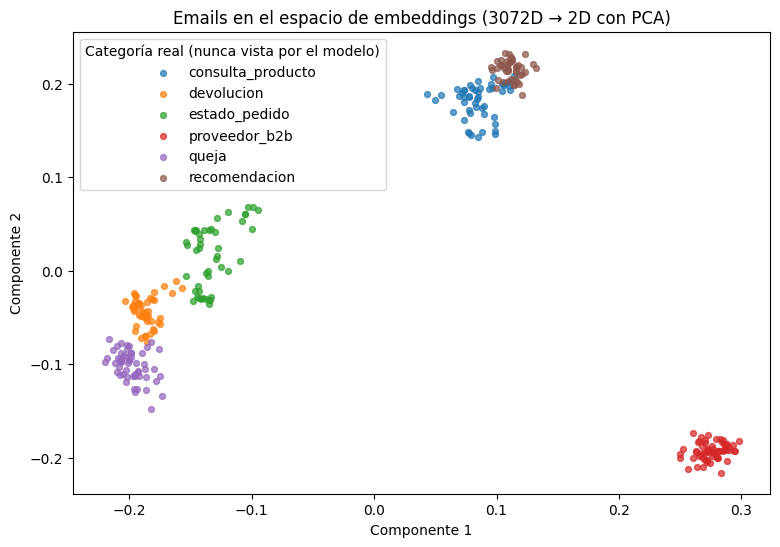

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

df_emb = client.query(f"""
  SELECT chunk_id, categoria_real, ml_generate_embedding_result AS emb
  FROM `{PROJECT_ID}.{DATASET}.email_embeddings`
  WHERE ml_generate_embedding_status = ''
""").to_dataframe()

X = np.vstack(df_emb.emb.values)          # matriz (n_chunks, 3072)
xy = PCA(n_components=2).fit_transform(X)  # proyección a 2D

plt.figure(figsize=(9, 6))
for cat in sorted(df_emb.categoria_real.unique()):
    m = (df_emb.categoria_real == cat).values
    plt.scatter(xy[m, 0], xy[m, 1], label=cat, s=18, alpha=0.7)
plt.legend(title="Categoría real (nunca vista por el modelo)")
plt.title(f"Emails en el espacio de embeddings ({X.shape[1]}D → 2D con PCA)")
plt.xlabel("Componente 1"); plt.ylabel("Componente 2")
plt.show()

> 🎓 **Este scatter es, por fin, el plano imaginario de la introducción — ahora con datos reales.** Allí colocamos tres emails a mano en dos ejes inventados; aquí el modelo ha colocado 300 en 3072 ejes aprendidos, y se **agrupan por tema espontáneamente**. Esto es lo que hace posible todo lo que viene después: buscar = encontrar los puntos más cercanos a la pregunta. (PCA a 2D es una simplificación brutal de 3072D: si dos clusters se solapan en el dibujo, no significa que se solapen en el espacio real.)

### 5.6 · Los vecinos más cercanos de un email concreto

Antes de usar `VECTOR_SEARCH`, hagámoslo "a mano" con `ML.DISTANCE` para entender qué hay debajo: calcular la distancia de un email contra **todos** los demás y ordenar.

In [21]:
ejemplo_id = df_emb.chunk_id.iloc[0]

client.query(f"""
  WITH ancla AS (
    SELECT ml_generate_embedding_result AS emb, content
    FROM `{PROJECT_ID}.{DATASET}.email_embeddings`
    WHERE chunk_id = '{ejemplo_id}'
  )
  SELECT e.chunk_id, e.categoria_real,
         ROUND(ML.DISTANCE(ancla.emb, e.ml_generate_embedding_result, 'COSINE'), 4) AS dist,
         SUBSTR(e.content, 1, 110) AS extracto
  FROM `{PROJECT_ID}.{DATASET}.email_embeddings` e, ancla
  ORDER BY dist
  LIMIT 6  -- el primero será él mismo (distancia 0)
""").to_dataframe()

,chunk_id,categoria_real,dist,extracto
0,msg-0296-0,consulta_producto,0.0000,"Asunto: Consulta sobre Ámbar Real\nDe: Javi Quintero\n\nBuenos días,\n\nEstoy interesado en el perfume Ámbar Real ("
1,msg-0196-0,consulta_producto,0.0310,"Asunto: Consulta sobre Ámbar Real\nDe: Hernando Alvarez Guijarro\n\nBuenos días,\n\nEstoy interesado en el perfume"
2,msg-0127-0,consulta_producto,0.0332,"Asunto: Consulta sobre Ámbar Real\nDe: Pepe Aníbal Olivares Salamanca\n\nBuenos días,\n\nEstoy interesado en el per"
3,msg-0233-0,consulta_producto,0.0353,"Asunto: Consulta sobre Ámbar Real\nDe: Nacio Valencia Marqués\n\nBuenos días,\n\nEstoy interesado en el perfume Ámb"
4,msg-0080-0,consulta_producto,0.0438,"Asunto: Consulta sobre Ámbar Real\nDe: Vasco Badía Cortés\n\nBuenos días, \n\nEstoy interesado en el perfume Ámbar"
5,msg-0112-0,consulta_producto,0.0444,"Asunto: Consulta sobre Ámbar Real\nDe: Fulgencio del Bermúdez\n\nBuenos días,\n\nEstoy interesado en el perfume Ámb"


> 🎓 Esto que acabamos de hacer (distancia contra todas las filas + `ORDER BY` + `LIMIT`) es exactamente lo que `VECTOR_SEARCH` hace por nosotros de forma optimizada. No hay magia: es SQL sobre una columna de arrays.

> 🧭 **Para llevar (sección 5):** (1) un embedding convierte significado en coordenadas: buscar pasa a ser medir distancias; (2) la calidad del retrieval se decide **aquí** — limpieza, serialización, modelo, task_type — no en el LLM; (3) los modelos se afinan según el *uso* del vector: documento y pregunta se vectorizan distinto; (4) más dimensiones ≠ siempre mejor: es un equilibrio calidad/coste que se mide, no se supone. Sustituye `ML.GENERATE_EMBEDDING` por una llamada a la API de OpenAI, Cohere o `sentence-transformers` y los cuatro puntos siguen siendo ciertos palabra por palabra.

---
# 6 · Búsqueda semántica con `VECTOR_SEARCH` ⏱️ ~10 min

**El concepto (válido en cualquier motor):** buscar los *k* vecinos más cercanos (**k-NN**) exige, en principio, comparar la consulta contra *todos* los vectores — exacto, pero de coste lineal. Cuando la tabla crece a millones, todos los motores del mundo (BigQuery, pgvector, Pinecone, FAISS, Elasticsearch...) recurren a la misma idea: índices **ANN** (*Approximate Nearest Neighbors*), que agrupan los vectores por zonas del espacio y solo exploran las zonas prometedoras. Se sacrifica un poco de exactitud —el *recall*: ¿cuántos de los k verdaderos encontré?— a cambio de órdenes de magnitud de velocidad. Es el clásico trade-off exacto/aproximado de las bases de datos, aplicado a geometría.

**¿Y cómo evita un índice ANN comparar contra todo?** La intuición, con las dos familias que ofrece BigQuery:

- **IVF** (*Inverted File*, "archivo invertido"): la idea de los **barrios**. Antes de indexar, se agrupan los vectores en cientos de clusters (barrios) y se calcula el centro de cada uno. Al buscar, primero se compara la pregunta solo contra los centros ("¿qué barrios me pillan cerca?") y luego se recorre casa por casa **solo dentro de los 2-3 barrios más cercanos**. De comparar contra 5 millones a comparar contra unos cientos + unas decenas de miles.
- **ScaNN / TreeAH** (algoritmo de Google): mismo espíritu, con los barrios organizados en árbol y los vectores guardados **comprimidos** para abaratar cada comparación; solo los finalistas se re-comparan con el vector completo.

Fuera de BigQuery existen otras familias con ideas propias — grafos de vecinos como **HNSW** (el estándar en pgvector/Elasticsearch: se "navega" saltando de vecino en vecino) o **DiskANN** (Microsoft: el grafo vive en disco y escala a miles de millones) — las retomaremos en el mapa final. Todas responden a la misma pregunta ("¿cómo no comparar contra todos?") con la misma moneda de cambio: velocidad a costa de un poco de *recall*.

**En BigQuery:** `VECTOR_SEARCH` encuentra los *k* más cercanos. Con nuestro volumen usa **fuerza bruta** (exacta), perfecta hasta decenas de miles de filas. Para tablas grandes se crea un **índice vectorial** (requiere ≥ 5.000 filas) eligiendo `IVF` o `TREE_AH`:

```sql
-- Solo como referencia (nuestra tabla no llega al mínimo):
CREATE VECTOR INDEX email_idx
ON email_embeddings(ml_generate_embedding_result)
OPTIONS (index_type = 'IVF', distance_type = 'COSINE');
```

Fíjate en el patrón de la consulta: la pregunta también pasa por `ML.GENERATE_EMBEDDING`, pero con `task_type = 'RETRIEVAL_QUERY'`.

▶️ **Qué hace esta celda:** empaqueta la búsqueda en una función reutilizable. Dentro pasan dos cosas: la pregunta se vectoriza al vuelo (con `task_type='RETRIEVAL_QUERY'`, ojo) y `VECTOR_SEARCH` devuelve los k chunks más cercanos. Usamos parámetros de consulta (`@pregunta`) en lugar de concatenar strings — higiene básica de SQL.

> 📍 **¿De dónde sale el `base.`?** No lo hemos definido nosotros: `VECTOR_SEARCH` devuelve las columnas de tu tabla agrupadas bajo el alias fijo **`base`** (por eso `base.chunk_id`, `base.content`...) más una columna propia, **`distance`**. Es la convención de la función, no SQL misterioso.

In [22]:
def buscar_emails(pregunta: str, k: int = 5) -> pd.DataFrame:
    """Devuelve los k chunks de email más relevantes para la pregunta."""
    sql = f"""
    SELECT base.chunk_id, base.categoria_real, base.fecha,
           base.content, ROUND(distance, 4) AS distancia
    FROM VECTOR_SEARCH(
      TABLE `{PROJECT_ID}.{DATASET}.email_embeddings`,
      'ml_generate_embedding_result',
      (SELECT ml_generate_embedding_result
       FROM ML.GENERATE_EMBEDDING(
         MODEL `{PROJECT_ID}.{DATASET}.embedding_model`,
         (SELECT @pregunta AS content),
         STRUCT(TRUE AS flatten_json_output, 'RETRIEVAL_QUERY' AS task_type))),
      top_k => @k, distance_type => 'COSINE')
    ORDER BY distance
    """
    cfg = bigquery.QueryJobConfig(query_parameters=[
        bigquery.ScalarQueryParameter("pregunta", "STRING", pregunta),
        bigquery.ScalarQueryParameter("k", "INT64", k),
    ])
    return client.query(sql, job_config=cfg).to_dataframe()

buscar_emails("clientes enfadados porque su perfume llegó roto o defectuoso")

,chunk_id,categoria_real,fecha,content,distancia
0,msg-0129-0,queja,2026-03-11 04:17:00,"Asunto: Queja - pedido PF-2026-54375\nDe: Judith Flores Madrigal\n\nEstimados señores:\n\nLes escribo muy decepcionado. En mi pedido PF-2026-54375, el perfume Oud Mediterráneo llegó con un problema: el frasco llegó roto. No es la primera vez que compro con ustedes y nunca había tenido incidencia...",0.1909
1,msg-0007-0,queja,2026-01-30 14:38:00,"Asunto: Queja - pedido PF-2026-20458\nDe: Guadalupe Pizarro Solé\n\nEstimados señores:\n\nLes escribo muy decepcionado. En mi pedido PF-2026-20458, el perfume Jardín de Sevilla llegó con un problema: el frasco llegó roto. No es la primera vez que compro con ustedes y nunca había tenido incidenci...",0.1949
2,msg-0016-0,queja,2026-05-20 22:03:00,"Asunto: Queja - pedido PF-2026-82512\nDe: Heriberto de Hoz\n\nEstimados señores:\n\nLes escribo muy decepcionado. En mi pedido PF-2026-82512, el perfume Noche de Azahar llegó con un problema: el frasco llegó roto. No es la primera vez que compro con ustedes y nunca había tenido incidencias.\n\nE...",0.1952
3,msg-0294-0,queja,2026-03-16 10:22:00,"Asunto: Queja - pedido PF-2026-18357\nDe: Octavia Guardiola\n\nEstimados señores:\n\nLes escribo muy decepcionado. En mi pedido PF-2026-18357, el perfume Noche de Azahar llegó con un problema: el frasco llegó roto. No es la primera vez que compro con ustedes y nunca había tenido incidencias.\n\n...",0.1953
4,msg-0212-0,queja,2026-01-12 10:24:00,"Asunto: Queja - pedido PF-2026-41147\nDe: Carina Borrego Narváez\n\nEstimados señores:\n\nLes escribo muy decepcionado. En mi pedido PF-2026-41147, el perfume Cuero y Vetiver llegó con un problema: el frasco llegó roto. No es la primera vez que compro con ustedes y nunca había tenido incidencias...",0.1969


> 🎓 **Observa**: la pregunta no comparte apenas palabras exactas con los emails (no dice "queja" ni "pedido") y aun así recupera las quejas. Eso es búsqueda **semántica**, no *keyword matching*. Probad ahora con `"proveedores que ofrecen esencias al por mayor"` o `"gente que pide consejo para regalar"`.

### Búsqueda híbrida: semántica + filtros SQL por metadatos

Aquí está la gran ventaja de tener los vectores **en una tabla SQL**: podemos combinar la búsqueda semántica con filtros clásicos (fecha, remitente, categoría...) pasando una **subconsulta** como primer argumento de `VECTOR_SEARCH`. El filtro se aplica *antes* de buscar (pre-filtrado), garantizando k resultados que cumplen la condición.

In [24]:
def buscar_emails_filtrado(pregunta: str, k: int = 5, desde: str = "2026-01-01") -> pd.DataFrame:
    """Búsqueda semántica SOLO sobre los emails posteriores a una fecha."""
    sql = f"""
    SELECT base.chunk_id, base.categoria_real, base.fecha,
           SUBSTR(base.content, 1, 120) AS extracto, ROUND(distance, 4) AS distancia
    FROM VECTOR_SEARCH(
      -- 👇 en lugar de TABLE, una subconsulta con el filtro SQL que quieras
      (SELECT * FROM `{PROJECT_ID}.{DATASET}.email_embeddings`
       WHERE fecha >= @desde),
      'ml_generate_embedding_result',
      (SELECT ml_generate_embedding_result
       FROM ML.GENERATE_EMBEDDING(
         MODEL `{PROJECT_ID}.{DATASET}.embedding_model`,
         (SELECT @pregunta AS content),
         STRUCT(TRUE AS flatten_json_output, 'RETRIEVAL_QUERY' AS task_type))),
      top_k => @k, distance_type => 'COSINE')
    ORDER BY distance
    """
    cfg = bigquery.QueryJobConfig(query_parameters=[
        bigquery.ScalarQueryParameter("pregunta", "STRING", pregunta),
        bigquery.ScalarQueryParameter("desde", "DATETIME", datetime.fromisoformat(desde)),
        bigquery.ScalarQueryParameter("k", "INT64", k),
    ])
    return client.query(sql, job_config=cfg).to_dataframe()

# Solo quejas/incidencias del último trimestre cargado
buscar_emails_filtrado("problemas con la entrega de pedidos", desde="2026-04-01")

,chunk_id,categoria_real,fecha,extracto,distancia
0,msg-0157-0,estado_pedido,2026-04-06 18:30:00,"Asunto: Estado de mi pedido PF-2026-87182\nDe: Carmelo Pinto-Correa\n\nHola, \n\nHace 2 días hice el pedido PF-2026-87182 que",0.2817
1,msg-0030-0,estado_pedido,2026-06-09 04:41:00,"Asunto: Estado de mi pedido PF-2026-34931\nDe: Javiera Jove Huertas\n\nHola,\n\nHace 4 días hice el pedido PF-2026-34931 que",0.2818
2,msg-0120-0,estado_pedido,2026-04-03 15:17:00,"Asunto: Estado de mi pedido PF-2026-24871\nDe: Azahara Belen Caballero Prada\n\nHola, \n\nHace 3 días hice el pedido PF-2026-",0.2820
3,msg-0107-0,estado_pedido,2026-05-31 11:36:00,"Asunto: Estado de mi pedido PF-2026-65723\nDe: Isidora Benítez Cervantes\n\nHola, \n\nHace 10 días hice el pedido PF-2026-657",0.2824
4,msg-0022-0,estado_pedido,2026-06-25 13:21:00,"Asunto: Estado de mi pedido PF-2026-26828\nDe: Timoteo Sosa Girón\n\nHola,\n\nHace 10 días hice el pedido PF-2026-26828 que i",0.2825


> 🧭 **Para llevar (sección 6):** conceptualmente, la búsqueda vectorial es un `ORDER BY distancia LIMIT k`; los índices ANN la hacen escalar sacrificando una exactitud que se puede medir (*recall*); y su poder real aparece al **combinarla con los filtros clásicos** de la base de datos (fechas, categorías, permisos). "Vector store" no es una categoría mágica de producto: es cualquier almacén capaz de hacer estas tres cosas.

---
# 7 · De la búsqueda semántica al RAG ⏱️ ~15 min

### El porqué: qué le falta a un LLM solo

Un LLM, por potente que sea, tiene cuatro problemas para responder sobre los emails de Esencia Ibérica: (1) **nunca los ha visto** — son datos privados, no estaban en su entrenamiento; (2) su conocimiento tiene **fecha de corte** — el email de ayer no existe para él; (3) si le preguntas igualmente, **inventará** una respuesta plausible y bien redactada (alucinación) — que suene bien es parte del problema; y (4) aunque acertara, **no puede citar fuentes**: imposible de auditar.

Hay tres maneras de darle ese conocimiento:

| Estrategia | Cuándo funciona / cuándo no |
|---|---|
| *Fine-tuning* (re-entrenar con tus datos) | Caro, lento, hay que repetirlo con cada email nuevo... y no elimina las alucinaciones |
| Meterlo **todo** en el prompt — esto tiene nombre: **CAG** (*Cache-Augmented Generation*) | Viable si el corpus es **pequeño y estable**; se rompe con volumen y con datos que cambian (ver abajo) |
| **Buscar en cada pregunta** justo lo necesario y responder solo con eso — **RAG** | 👉 Nuestra elección, y la dominante con datos vivos y voluminosos |

Regla rápida: **corpus pequeño y quieto → valora CAG; corpus grande o cambiante → RAG**. (La comparación con calma, en el anexo al final de esta sección — ahora toca ver el RAG funcionando.)

Por eso aquí domina RAG: el conocimiento vive en una **base de datos** (actualizable al segundo, auditable, con permisos), no en los pesos del modelo ni congelado en una caché. El LLM pasa de ser *la fuente* a ser *el redactor*.

### El cómo: buscador + dos pasos

Hasta aquí tenemos un **buscador semántico**: le das una pregunta y devuelve *filas de una tabla*. Útil, pero el usuario quiere una **respuesta redactada**, no 5 filas. El salto de buscador a RAG consiste en añadir dos pasos alrededor de lo que ya tenemos:

| Paso | Qué hace | Con qué |
|---|---|---|
| **R**etrieval | Recupera los k chunks más relevantes | `VECTOR_SEARCH` ✅ (ya lo tenemos) |
| **A**ugmentation | Monta un prompt: instrucciones + chunks recuperados + pregunta | Python (un *f-string*) |
| **G**eneration | El LLM redacta la respuesta **basándose solo en ese contexto** | Gemini 2.5 Flash |

Ojo al detalle de la fila central: la "A" de RAG no requiere ninguna tecnología especial. Un *f-string* es simplemente la plantilla de texto de Python — `f"Hola, {nombre}"` sustituye `{nombre}` por su valor — así que "montar el prompt" es literalmente **pegar texto**: las instrucciones fijas, los chunks que devolvió la búsqueda y la pregunta del usuario, todo en un mismo string. Lo veréis dentro de la función `responder()`.

Es decir: **RAG = tu buscador + un prompt bien montado + un LLM**. Nada más. Toda la "inteligencia documental" del sistema vive en las fases anteriores (serialización, chunking, embeddings): si el retrieval trae los emails equivocados, el mejor LLM del mundo responderá mal.

**El prompt de augmentation tiene tres reglas de oro:**
1. *Grounding*: "responde EXCLUSIVAMENTE con el contexto proporcionado" → contra alucinaciones.
2. *Citación*: "cita los IDs de los emails que uses" → trazabilidad, puedes auditar cada afirmación con un `SELECT`.
3. *Escape*: "si el contexto no basta, dilo" → el sistema sabe decir "no lo sé".

**¿Y por qué no pasarle los 300 emails enteros al LLM y ahorrarse todo esto?** Con 300 quizá podrías; con los volúmenes reales (cientos de miles) es inviable: coste por token, latencia, límite de contexto, y el fenómeno *lost in the middle* (los LLM se pierden con contextos enormes). El retrieval selecciona; el LLM redacta.

▶️ **Qué hace esta celda:** el RAG completo en una función de ~20 líneas. `responder()` = (1) llama a `buscar_emails` → (2) monta el prompt con los chunks recuperados y las tres reglas de oro (grounding, citación, escape) → (3) se lo pasa a Gemini. Leed el prompt con calma: *es* la parte de "Augmentation".

In [ ]:
from google import genai

genai_client = genai.Client(vertexai=True, project=PROJECT_ID, location="global")

def responder(pregunta: str, k: int = 5, verbose: bool = True) -> str:
    # 1) Retrieval
    docs = buscar_emails(pregunta, k)
    contexto = "\n\n---\n\n".join(
        f"[{r.chunk_id} | {r.categoria_real} | {r.fecha:%d/%m/%Y}]\n{r.content}"
        for r in docs.itertuples()
    )
    # 2) Augmentation
    prompt = f"""Eres el asistente interno de Esencia Ibérica, S.L. (tienda online de perfumes).
Responde a la pregunta del equipo usando EXCLUSIVAMENTE los emails del contexto.
Cita los IDs de los emails en los que te basas. Si el contexto no basta, dilo claramente.

### Contexto (emails recuperados):
{contexto}

### Pregunta:
{pregunta}"""
    # 3) Generation  (si hay errores 429/latencia: cambia a model="gemini-2.0-flash")
    resp = genai_client.models.generate_content(model="gemini-2.5-flash", contents=prompt)
    if verbose:
        print(f"🔎 Recuperados {len(docs)} emails | categorías: {docs.categoria_real.unique().tolist()}\n")
    return resp.text or "(respuesta vacía o bloqueada por el filtro de seguridad — reintenta)"

print(responder("¿Cuáles son los problemas más frecuentes en las quejas de los clientes?"))

▶️ **Qué hacen estas dos celdas:** más preguntas de prueba, elegidas para tocar categorías distintas (recomendaciones, proveedores). Fijaos en cada respuesta en qué emails se apoya (los IDs citados) — eso es la trazabilidad que un LLM solo no puede dar.

In [ ]:
print(responder("¿Qué notas olfativas piden más los clientes que buscan recomendación?"))

In [ ]:
print(responder("Resume las ofertas que nos han hecho los proveedores y sus condiciones de pago"))

> 🎓 **Anti-alucinación en acción:** preguntad algo que NO esté en los emails, p. ej. `responder("¿Cuál fue la facturación de la empresa en 2025?")`. Un RAG bien instruido debe responder que el contexto no contiene esa información.

> 🧭 **Para llevar (sección 7):** RAG no es una tecnología, es una **arquitectura**: separar el *conocimiento* (base de datos — actualizable, auditable, con permisos) del *razonamiento* (LLM — intercambiable). El retrieval decide qué puede saber el sistema; el prompt decide qué le está permitido decir; el LLM solo redacta. Corolario práctico: cuando un RAG responde mal se depura **de abajo arriba** — ¿estaba el dato en la tabla? ¿lo recuperó la búsqueda? ¿llegó al prompt? — y solo en último lugar se culpa al LLM.

### 📎 Anexo: RAG vs. CAG, con calma

CAG no es una idea ingenua: los modelos actuales admiten contextos enormes (millones de tokens) y el *prompt caching* permite pagar ese contexto gigante una vez y reutilizarlo en cada pregunta. Para un corpus **pequeño, estable y sin permisos por usuario** (un manual de producto, la normativa interna, unas FAQ), CAG es más simple que RAG: sin embeddings, sin vector store, sin riesgo de que el retrieval falle — todo está siempre "a la vista" del modelo.

¿Por qué aquí elegimos RAG igualmente? Por las tres cosas que nuestros emails tienen y un manual no: (1) **volumen creciente** — 300 hoy, millones en producción: no caben, y aunque cupieran, el *lost in the middle* degrada la atención sobre contextos enormes; (2) **datos vivos** — cada email nuevo invalidaría la caché que hace rentable a CAG; (3) **control fino** — con RAG decides *por pregunta* qué se le enseña al modelo (filtros, permisos, trazabilidad de qué 5 emails sustentan la respuesta). Y no son excluyentes: hay diseños híbridos (lo estable en caché + lo fresco por retrieval).

---
# 8 · Vectorización incremental: el patrón de producción ⏱️ ~5 min

En la vida real los emails **no dejan de llegar**. Re-vectorizar toda la tabla cada día sería tirar el dinero: hay que vectorizar **solo las filas nuevas**. La pregunta clave es: *¿qué chunks todavía no tienen embedding?* — y esa pregunta tiene un nombre en el mundo de las bases de datos: **anti-join**.

### ¿Qué es un anti-join?

Un `JOIN` normal responde "¿qué filas de A **tienen** pareja en B?". El anti-join responde justo lo contrario: **"¿qué filas de A NO tienen pareja en B?"**. Con nuestras dos tablas:

```
   A: emails_chunked            B: email_embeddings           ANTI-JOIN (A sin pareja en B)
   ┌───────────────┐            ┌───────────────┐
   │ msg-0001-0    │──pareja───▶│ msg-0001-0 ✓  │
   │ msg-0002-0    │──pareja───▶│ msg-0002-0 ✓  │
   │ msg-0300-0    │──── ✗      │               │──▶  msg-0300-0  ← solo estos
   │ msg-0301-0    │──── ✗      │               │──▶  msg-0301-0     se vectorizan
   └───────────────┘            └───────────────┘
```

En SQL no existe la palabra `ANTI JOIN`; se escribe con `WHERE NOT EXISTS` (la forma preferida: maneja bien los NULL y el optimizador la entiende):

```sql
INSERT INTO email_embeddings
SELECT * FROM ML.GENERATE_EMBEDDING(MODEL ...,
  (SELECT ... FROM emails_chunked c          -- para cada chunk c...
   WHERE NOT EXISTS (                        -- ...que NO tenga ya
     SELECT 1 FROM email_embeddings e        --    una fila en embeddings
     WHERE e.chunk_id = c.chunk_id)), ...)   --    con su mismo id
```

Leído en voz alta: *"vectoriza cada chunk para el que no exista todavía un embedding con su mismo `chunk_id`"*. (Veréis también las variantes `NOT IN (...)` y `LEFT JOIN ... WHERE b.id IS NULL` — son tres formas de escribir el mismo anti-join.)

Lo elegante del patrón es que es **idempotente**: si lo ejecutas dos veces seguidas, la segunda no hace nada (ya no hay filas sin pareja) — puedes programarlo cada hora sin miedo a duplicar. En producción, eso es una *scheduled query* de BigQuery. Simulémoslo: llegan 10 emails nuevos.

In [ ]:
# 1) Llegan 10 emails nuevos → a la tabla raw (WRITE_APPEND)
#    ⚠️ El índice inicial se deriva de la TABLA, no de una constante: así esta
#    celda es re-ejecutable sin duplicar message_id (idempotencia de verdad).
ultimo = int(client.query(f"""
    SELECT MAX(CAST(SUBSTR(message_id, 5) AS INT64)) AS m
    FROM `{PROJECT_ID}.{DATASET}.emails_raw`
""").to_dataframe().m[0])

nuevos = []
for i in range(ultimo + 1, ultimo + 11):
    categoria = random.choice(list(GENERADORES.keys()))
    nombre = fake.name()
    subject, body = GENERADORES[categoria](nombre)
    nuevos.append({
        "message_id": f"msg-{i:04d}", "thread_id": f"thr-{i:04d}",
        "from_email": fake.email(), "from_name": nombre,
        "to_email": "atencion@esenciaiberica.es",
        "fecha": BASE_DATE + timedelta(days=181), "subject": subject,
        "body": body, "categoria_real": categoria,
    })
client.load_table_from_dataframe(
    pd.DataFrame(nuevos), f"{PROJECT_ID}.{DATASET}.emails_raw",
    bigquery.LoadJobConfig(write_disposition="WRITE_APPEND")).result()

# 2) Re-ejecutamos limpieza y chunking (recalcular es barato a esta escala;
#    en producción, ambos pasos se harían también de forma incremental)
client.query(sql_limpieza).result()
reconstruir_chunks()

# 3) 🔑 Vectorizamos SOLO los chunks que aún no tienen embedding
#    ⚠️ El SELECT * funciona porque esta subconsulta es idéntica a la del CTAS
#    de la sección 5 (mismo orden de columnas). Si editas una, edita la otra.
#    En producción: lista de columnas explícita o MERGE.
sql_incremental = f"""
INSERT INTO `{PROJECT_ID}.{DATASET}.email_embeddings`
SELECT *
FROM ML.GENERATE_EMBEDDING(
  MODEL `{PROJECT_ID}.{DATASET}.embedding_model`,
  (SELECT chunk_id, message_id, fecha, from_email, categoria_real, content
   FROM `{PROJECT_ID}.{DATASET}.emails_chunked` c
   WHERE NOT EXISTS (
     SELECT 1 FROM `{PROJECT_ID}.{DATASET}.email_embeddings` e
     WHERE e.chunk_id = c.chunk_id)),
  STRUCT(TRUE AS flatten_json_output, 'RETRIEVAL_DOCUMENT' AS task_type)
)
WHERE ml_generate_embedding_status = ''   -- 🛡️ y solo si se vectorizaron bien
"""
job = client.query(sql_incremental)
job.result()
print(f"✅ Vectorizados {job.num_dml_affected_rows} chunks nuevos (y solo esos)")

> 🎓 Fijaos: hemos vectorizado 10 filas, no 300. El RAG ya "conoce" los emails nuevos sin reconstruir nada — probad `responder()` sobre algo que esté solo en ellos. Este anti-join programado es el 90% de un pipeline de vectorización en producción. **Bonus:** como filtramos por `status`, este mismo INSERT es también el **mecanismo de reintento** — si en la sección 5 quedaron chunks sin vectorizar por cuota, esta celda los recupera.

> ⚖️ **Honestidad de escala:** en esta demo, la limpieza y el chunking se recalculan enteros (pandas ida y vuelta a Colab) — a partir de ~100k emails eso sería el cuello de botella, y ambos pasos se harían también incrementales (mismo patrón anti-join sobre `emails_clean` y `emails_chunked`). Y cuando la tabla supere las decenas de miles de filas, el paso siguiente natural es `CREATE VECTOR INDEX` (sección 6).

---
# 9 · Evaluación, ejercicios y limpieza ⏱️ ~8 min

### Mini-evaluación del retrieval

Como guardamos la **categoría real** de cada email, podemos medir la *precisión@k*: si busco quejas, ¿cuántos de los top-k son realmente quejas?

▶️ **Qué hace esta celda:** para cada categoría, lanza una consulta "típica" y mide qué fracción de los 5 resultados pertenece realmente a esa categoría (*precision@5*), usando el ground truth que guardamos en la sección 1. Es la versión mínima de cómo se evalúa un retrieval en serio.

In [ ]:
consultas_test = {
    "queja":         "clientes muy descontentos con productos que llegaron mal",
    "devolucion":    "gente que quiere devolver un perfume y pide el procedimiento",
    "estado_pedido": "dónde está mi pedido, no me llega el número de seguimiento",
    "proveedor_b2b": "ofertas comerciales de esencias al por mayor con muestras",
}

K = 5
resultados = []
for cat_esperada, consulta in consultas_test.items():
    docs = buscar_emails(consulta, K)
    aciertos = (docs.categoria_real == cat_esperada).sum()
    resultados.append({"categoria": cat_esperada, f"precision@{K}": aciertos / K})

pd.DataFrame(resultados)

### Ejercicio en clase — comprobar empíricamente que el `task_type` importa

En 5.3 lo prometimos; aquí está la prueba, con el código ya preparado. `buscar_emails_mal` es idéntica a `buscar_emails` con **un solo cambio**: vectoriza la pregunta como si fuera un documento (`RETRIEVAL_DOCUMENT` en vez de `RETRIEVAL_QUERY`). Comparamos la precisión@5 de ambas — ejecutad y discutid el resultado.

In [ ]:
# EJERCICIO 1 (en clase) — código preparado: solo ejecutar y comparar
def buscar_emails_mal(pregunta: str, k: int = 5) -> pd.DataFrame:
    """Idéntica a buscar_emails, pero con el task_type EQUIVOCADO a propósito."""
    sql = f"""
    SELECT base.categoria_real
    FROM VECTOR_SEARCH(
      TABLE `{PROJECT_ID}.{DATASET}.email_embeddings`,
      'ml_generate_embedding_result',
      (SELECT ml_generate_embedding_result
       FROM ML.GENERATE_EMBEDDING(
         MODEL `{PROJECT_ID}.{DATASET}.embedding_model`,
         (SELECT @pregunta AS content),
         STRUCT(TRUE AS flatten_json_output,
                'RETRIEVAL_DOCUMENT' AS task_type))),   -- 👈 el único cambio
      top_k => @k, distance_type => 'COSINE')
    """
    cfg = bigquery.QueryJobConfig(query_parameters=[
        bigquery.ScalarQueryParameter("pregunta", "STRING", pregunta),
        bigquery.ScalarQueryParameter("k", "INT64", k),
    ])
    return client.query(sql, job_config=cfg).to_dataframe()

comparativa = []
for cat, consulta in consultas_test.items():
    bien = (buscar_emails(consulta, K).categoria_real == cat).sum() / K
    mal  = (buscar_emails_mal(consulta, K).categoria_real == cat).sum() / K
    comparativa.append({"categoria": cat,
                        "task_type correcto": bien, "task_type equivocado": mal})
pd.DataFrame(comparativa)

### Ejercicios para casa (cada uno con su pista)

2. **Dimensiones**: crea un segundo modelo con `output_dimensionality = 768`, vectoriza en otra tabla y compara precisión@5 y tamaño físico. *Pista:* el tamaño se consulta en `INFORMATION_SCHEMA.TABLE_STORAGE`, la vista del sistema con los bytes de cada tabla: `SELECT table_name, total_logical_bytes FROM \`region-us\`.INFORMATION_SCHEMA.TABLE_STORAGE WHERE table_schema = 'rag_perfumes'`.
3. **Serialización fila→documento**: re-vectoriza usando solo `body_clean` (sin asunto ni remitente) y mide el impacto en la precisión. *Pista:* edita la línea `texto = f"..."` de `reconstruir_chunks()` y re-ejecuta desde la sección 5. Acabas de cuantificar cuánto vale el diseño del documento.
4. **Clasificador gratis**: clasifica un email nuevo por voto mayoritario de sus 3 vecinos. *Pista:* `buscar_emails(texto_del_email, k=3).categoria_real.mode()[0]` — un k-NN semántico sin entrenar nada.
5. **Escalado** (para debatir): con 5 millones de emails, ¿qué cambiarías? (índice vectorial IVF/TreeAH, particionado por fecha, `output_dimensionality`, limpieza/chunking incrementales...)
6. **Adjuntos** (diseño en papel): dibuja el pipeline para incorporar los PDFs adjuntos de los emails — *object table* sobre Cloud Storage, extracción de texto, chunks con `message_id` del email padre, y cómo afectaría a `buscar_emails` y a `responder`.

### Ideas para producción

- **Orquestar lo incremental**: la celda de la sección 8, como *scheduled query* o en Dataform, cada X horas.
- **Generación también en SQL**: `AI.GENERATE` / `ML.GENERATE_TEXT` permiten hacer el paso de generación sin salir de BigQuery.
- **Orquestación desde una app**: si el RAG crece (multi-fuente, agentes, re-ranking), los frameworks actuales son **LlamaIndex** (el referente para RAG documental), **Haystack** (pipelines estructurados, mentalidad de producción) y **DSPy** (optimiza los prompts programáticamente); BigQuery tiene conector oficial de vector store para estos ecosistemas.
- **Evaluación seria**: **RAGAS** automatiza las métricas que aquí hicimos a mano (precisión del retrieval, fidelidad de la respuesta al contexto, relevancia).
- **Privacidad**: con emails reales, anonimiza o controla accesos (los embeddings pueden filtrar información sensible).

### 🧹 Limpieza de recursos

Ejecuta esta celda al terminar para no dejar nada facturable en el proyecto.

In [ ]:
BORRAR = False  # ⚠️ cambia a True para borrar todo

if BORRAR:
    client.delete_dataset(f"{PROJECT_ID}.{DATASET}", delete_contents=True, not_found_ok=True)
    !bq rm --connection --force {PROJECT_ID}.{LOCATION}.{CONN_ID}
    print("🧹 Dataset y conexión eliminados")
else:
    print("Nada borrado (BORRAR = False)")

---
## 🧪 Autoevaluación — cinco preguntas, cero código

Antes del mapa final, comprobad qué se ha quedado. Todas las respuestas están en los recuadros 🧭 "Para llevar":

1. ¿Por qué la pregunta y el documento se vectorizan con `task_type` distinto, si van al mismo espacio?
2. Vuestro RAG responde mal a una pregunta. ¿En qué orden depuráis, y por qué el LLM es el último sospechoso?
3. ¿En qué caso concreto elegiríais CAG en lugar de RAG? ¿Y un híbrido?
4. ¿Por qué vectorizamos *chunks* y no emails enteros? ¿Qué se rompería con documentos muy largos?
5. ¿Qué compra exactamente un índice ANN y con qué moneda lo paga?

*(Para el instructor: 3-4 min en parejas + puesta en común relámpago funciona muy bien aquí.)*

---
## 🧭 Mapa final: los conceptos, más allá de la tecnología

Todo lo que habéis hecho hoy con BigQuery se hace, con otra sintaxis, en cualquier stack. Lo que no cambia es la columna de la izquierda:

| Concepto universal | Hoy lo hicimos con | Equivalentes en otros stacks |
|---|---|---|
| Cargar crudo, transformar dentro (ELT) | Load jobs + SQL | Postgres + dbt, Snowflake, DuckDB |
| Serialización fila → documento | f-string en Python | Idéntico en cualquier stack |
| Chunking con solape | Función Python propia | Chonkie, splitters de LlamaIndex |
| Texto → vector (embedding) | `ML.GENERATE_EMBEDDING` + Vertex | APIs de OpenAI/Cohere, `sentence-transformers` |
| Vector asimétrico documento/query | `task_type` | Prefijos de instrucción (E5, BGE...) |
| Búsqueda k-NN por coseno | `VECTOR_SEARCH` | pgvector (`<=>`), FAISS, Pinecone |
| Índice ANN (velocidad por exactitud) | IVF / TreeAH | HNSW (pgvector, Elasticsearch), ScaNN |
| Búsqueda híbrida (semántica + filtros) | Subconsulta SQL | *Metadata filters* (Pinecone, Weaviate) |
| Augmentation con grounding y citas | Prompt + Gemini | Idéntico con cualquier LLM |
| Vectorización incremental | `INSERT ... WHERE NOT EXISTS` | Idéntico: es lógica de datos, no de IA |

Si entendéis la columna izquierda, cualquier fila de la derecha se aprende en una tarde.

### El mismo curso en las otras nubes

¿Y si vuestra empresa no usa Google Cloud? El patrón "vectoriza dentro del warehouse, en SQL" existe en todas partes, con estos nombres:

| Plataforma | El equivalente de lo que hicimos hoy | Novedad reciente (2026) |
|---|---|---|
| **Snowflake** | El análogo más directo: **Cortex** — `AI_EMBED` genera embeddings en SQL (como `ML.GENERATE_EMBEDDING`), tipo `VECTOR` nativo, `VECTOR_COSINE_SIMILARITY` para la distancia, y **Cortex Search** como servicio de retrieval híbrido ya montado | Cortex Search ha ganado **multi-índice** (varias columnas buscables por servicio), **Batch Search** para trabajos masivos offline, y admite **embeddings propios** de terceros |
| **Microsoft** | **Fabric** (warehouse), **Azure AI Search** (servicio de búsqueda vectorial/híbrida), tipo `VECTOR` nativo en **Azure SQL**, embeddings vía Azure OpenAI | **Azure HorizonDB** (Build, jun 2026): PostgreSQL gestionado "para la era IA" — la extensión `azure_ai` invoca embeddings y LLMs **desde SQL dentro de la BD**, índice **DiskANN** hasta 16.000 dimensiones y búsqueda híbrida integrada |
| **AWS** | **Aurora/RDS PostgreSQL + pgvector** (vectores en la BD relacional), **OpenSearch** como motor vectorial, **Bedrock Knowledge Bases** como RAG gestionado de punta a punta | **S3 Vectors** (GA, dic 2025): el primer almacenamiento de objetos con vectores **nativos** — hasta 2.000 millones de vectores por índice, arquitectura "storage-first" con ~90% menos coste para RAG masivo; se enchufa como capa de vectores de Bedrock KB y OpenSearch |
| **Databricks** | **Databricks AI Search** (antes Vector Search), integrado con las tablas Delta y su ecosistema de modelos | Renombrado y ampliado: *storage-optimized endpoints* (miles de millones de vectores separando cómputo y almacenamiento, indexación 20× más rápida) y **Lakebase Search**: retrieval híbrido vectorial + full-text **nativo en Postgres** |

Y un detalle que valida lo que habéis aprendido hoy: fijaos en la **dirección** de todas estas novedades de 2025-2026 — HorizonDB mete los modelos *dentro* del Postgres, S3 Vectors mete los vectores *dentro* del almacenamiento, Lakebase mete el retrieval *dentro* de la base de datos. La industria entera converge hacia la tesis de este curso: **los vectores viven donde viven los datos, no en un sistema aparte**. Ninguna nube os pedirá conceptos nuevos: en todas hay un "texto → vector en SQL", una función de distancia, un índice ANN y un LLM al final.

---
## 📚 Recursos para seguir

- [`ML.GENERATE_EMBEDDING`](https://cloud.google.com/bigquery/docs/reference/standard-sql/bigqueryml-syntax-generate-embedding) · [`VECTOR_SEARCH`](https://cloud.google.com/bigquery/docs/reference/standard-sql/search_functions#vector_search) · [Introducción a vector search en BigQuery](https://cloud.google.com/bigquery/docs/vector-search-intro)
- [Notebook oficial de RAG con BigQuery](https://github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/use-cases/retrieval-augmented-generation/rag_vector_embedding_in_bigquery.ipynb) (GoogleCloudPlatform/generative-ai)
- Chunking avanzado: [Chonkie](https://github.com/chonkie-inc/chonkie) · Orquestación: [LlamaIndex](https://docs.llamaindex.ai/) y [Haystack](https://haystack.deepset.ai/) · Evaluación: [RAGAS](https://docs.ragas.io/)

*Curso: De la bandeja de entrada al RAG — Esencia Ibérica, S.L. (datos 100% sintéticos).*